# Gradient-Based Attribution vs PCI

> **Summary.** Compares PCI's responsibility scores against gradient / sensitivity-based attribution methods on a controlled synthetic model. Probes invariance to feature scale, sensitivity to priors, and the differential causal effect (DCE). Targets the paper's discussion of why gradient methods are not causally faithful even when their numbers look plausible.

### Gradient scores against causal responsibility

Suppose a model decides an applicant's credit limit from a few inputs, and we want to know *which input was responsible* for the decision in a particular case. A tempting answer for a continuous input is the gradient, the amount the output moves when we wiggle the input. That is the idea behind the differential causal effect (DCE) and, more broadly, gradient- and sensitivity-based attribution. It is cheap, it is local, and its numbers usually look reasonable.

This notebook asks whether those numbers are *causally faithful*. We build a deliberately transparent synthetic model in which we know the right answer (age strongly drives the credit limit, time of day barely matters), and we score the inputs two ways: with the gradient (DCE) and with PCI (Probabilistic Causal Impact), the responsibility measure developed in the paper. We then run two diagnostics that any trustworthy attribution should pass:

1. Invariance to feature scale. Measuring time in hours vs.\ minutes is a cosmetic relabelling; it should not change which input is judged more responsible.
2. Sensitivity to priors. How unusual the factual input is *should* matter to a responsibility claim.

Section&nbsp;6 of the paper develops the result. DCE fails the first test (its time-of-day score changes by a factor of $\sim 60$ under the unit change, and it can rank time above age) even though its raw numbers look plausible, while PCI is invariant to the rescaling and tracks the prior in the intended way. Gradient methods are not causally faithful, and a model this small already makes that concrete.


In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyro
import pyro.distributions as dist
import seaborn as sns
import torch
from IPython.display import Image, display
from pyro.distributions import transforms

from pci.explanation.regime import condition_on_interventional_regime
from pci.explanation.scores import abs_diff_score
from pci.explanation.searchable import SearchableModel
from pci.explanation.thin_search import ThinSearchSampler

smoke_test = "CI" in os.environ

import os
import pickle

sample_size = 10 if smoke_test else 3000
n_size = 5 if smoke_test else 500
num_search_samples = 10 if smoke_test else 5000

# Seeded so every number and figure below reproduces exactly on a fresh run.
# pyro.set_rng_seed seeds torch, python random and numpy together.
SEED = 0
pyro.set_rng_seed(SEED)


In [2]:
def add_line_end_label(ax, x, y, text, color="black"):
    ax.text(
        x,  # apply horizontal shift
        y,
        f"{text}",
        fontsize=14,
        ha="left",
        va="center",
        color=color,
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="white",
            ec=color,
            lw=1.2,
            alpha=0.85,
        ),
    )

## Overview

### Motivations

In a typical setting ATE is $\mathbb{E}(Y\vert do(X=1)) - \mathbb{E}(Y\vert do(X=0))$, i.e. $\mathbb{E}(Y_{X=1} - Y_{X=0})$. If the cause is categorical, one chooses levels of interest and estimates $\mathbb{E}(Y_{X=a} - Y_{X=b})$ for two categories $a, b$. One natural extension to a continuous cause is to take the limit of a shrinking contrast:

> If we want to generalize  $\mathbb{E}(Y_{X=1} - Y_{X=0})$ to the case where $X$ is continuous, we arrive at derivative calculus. For some baseline $do(X=x)$, imagine changing the intervention value $x$ by some small amount $\Delta$, i.e. $do(X=x+\Delta)$. Taking the difference between the two outcomes, we get $\mathbb{E}(Y_{X=x+\Delta} - Y_{X=x})$, then we can ask, what is the rate of change of $\mathbb{E}(Y_{X})$ as we make $\Delta$ infinitesimally smaller. (Ness, *Causal AI*, 2025, §7.4.3.)

This suggests using $\frac{d\,\mathbb{E}(Y_{X=x})}{dx}$, and, potentially, its conditional counterparts.


Generalizing to multiple inputs, let the intervention vector be
$\mathbf{X} = (X_1,\ldots,X_d)$ and denote the interventional mean function by
$$m(\mathbf{x}) = \mathbb{E}\bigl(Y_{\mathbf{X}=\mathbf{x}}\bigr).$$

For a small perturbation $\mathbf{x} \mapsto \mathbf{x} + \boldsymbol{\Delta}$,
the causal contrast

$$m(\mathbf{x} + \boldsymbol{\Delta}) - m(\mathbf{x})$$

captures the effect of jointly modifying several causal variables.

Taking limits yields the **causal gradient**

$$\nabla_{\mathbf{x}}\, m(\mathbf{x})
= \left(
\frac{\partial}{\partial x_1}\mathbb{E}(Y_{\mathbf{X}=\mathbf{x}}),
\;\ldots\;,
\frac{\partial}{\partial x_d}\mathbb{E}(Y_{\mathbf{X}=\mathbf{x}})
\right),$$
where each partial derivative is the **differential causal effect** (DCE) of a single variable at the
intervention point $\mathbf{x}$.

This approach was taken by Butler, Feng and Djurić (*A Differential Measure of Strength of Causation*, IEEE Signal Processing Letters, vol. 29, 2022), who extended ATE to nonlinear functions and allowed for modulatory effects of covariates. They introduced DCE in the context of Gaussian Process regression (GPR), where the posterior expected mean can be written as $\sum_{n=1}^N k(x, x^{(n)}) \alpha_n$, with $x^{(n)}$ training inputs, $x$ a test point, and $\alpha_n$ the $n$-th entry of $(\mathbf{K} + \sigma^2 \mathbf{I})^{-1}y$. DCE then has the closed form $\frac{\partial \hat{F}}{\partial x_i} = \sum_{n=1}^{N} \frac{\partial k (x, x^{(n)})}{\partial x_i}\alpha_n$.

Our goal in this notebook is to build up some minimally interesting models that contrast DCE with PCI. The main differences we will illustrate:


1. DCE is restricted to relationships of the form $y := F(\mathbf{X}, \epsilon)$, with $F$ differentiable. PCI requires only that the causal model be sampleable; the choice of inference algorithm for the expanded model is up to the user. Throughout we use Monte Carlo, but other inference algorithms can be substituted.
2. The units of DCE are determined by the units of both $Y$ and $\mathbf{X}$, which makes DCE harder to compare across features. The choice of input units has little impact on the PCI score, because inputs are integrated out using the densities they receive in the necessity and sufficiency worlds.
3. The PCI score does depend on input values, but does not change as abruptly as DCE can. The change depends on where a given input sits relative to its necessity/sufficiency distribution. In our example this yields a notion that captures non-null responsibility even in flat regions of the response surface, without being extremely sensitive to very local changes.

### The model and exploration setup

We model an applicant's credit limit as a function of age and the time of day at which their application is evaluated. The model reflects the notion that credit limits increase sharply within a limited age range, and that applications reviewed in the morning or immediately after lunch are associated with slightly higher limits, potentially reflecting systematic variations in reviewer disposition throughout the day. Unconditioned inputs are assumed to come from probability distributions (taken to be normal for simplicity), and we wrap the deterministic component within a Bayesian model that incorporates these uncertainties.

We consider four settings along two axes. The first axis is whether time is measured in minutes or in hours. The deterministic models give qualitatively the same predictions modulo this scale transformation.

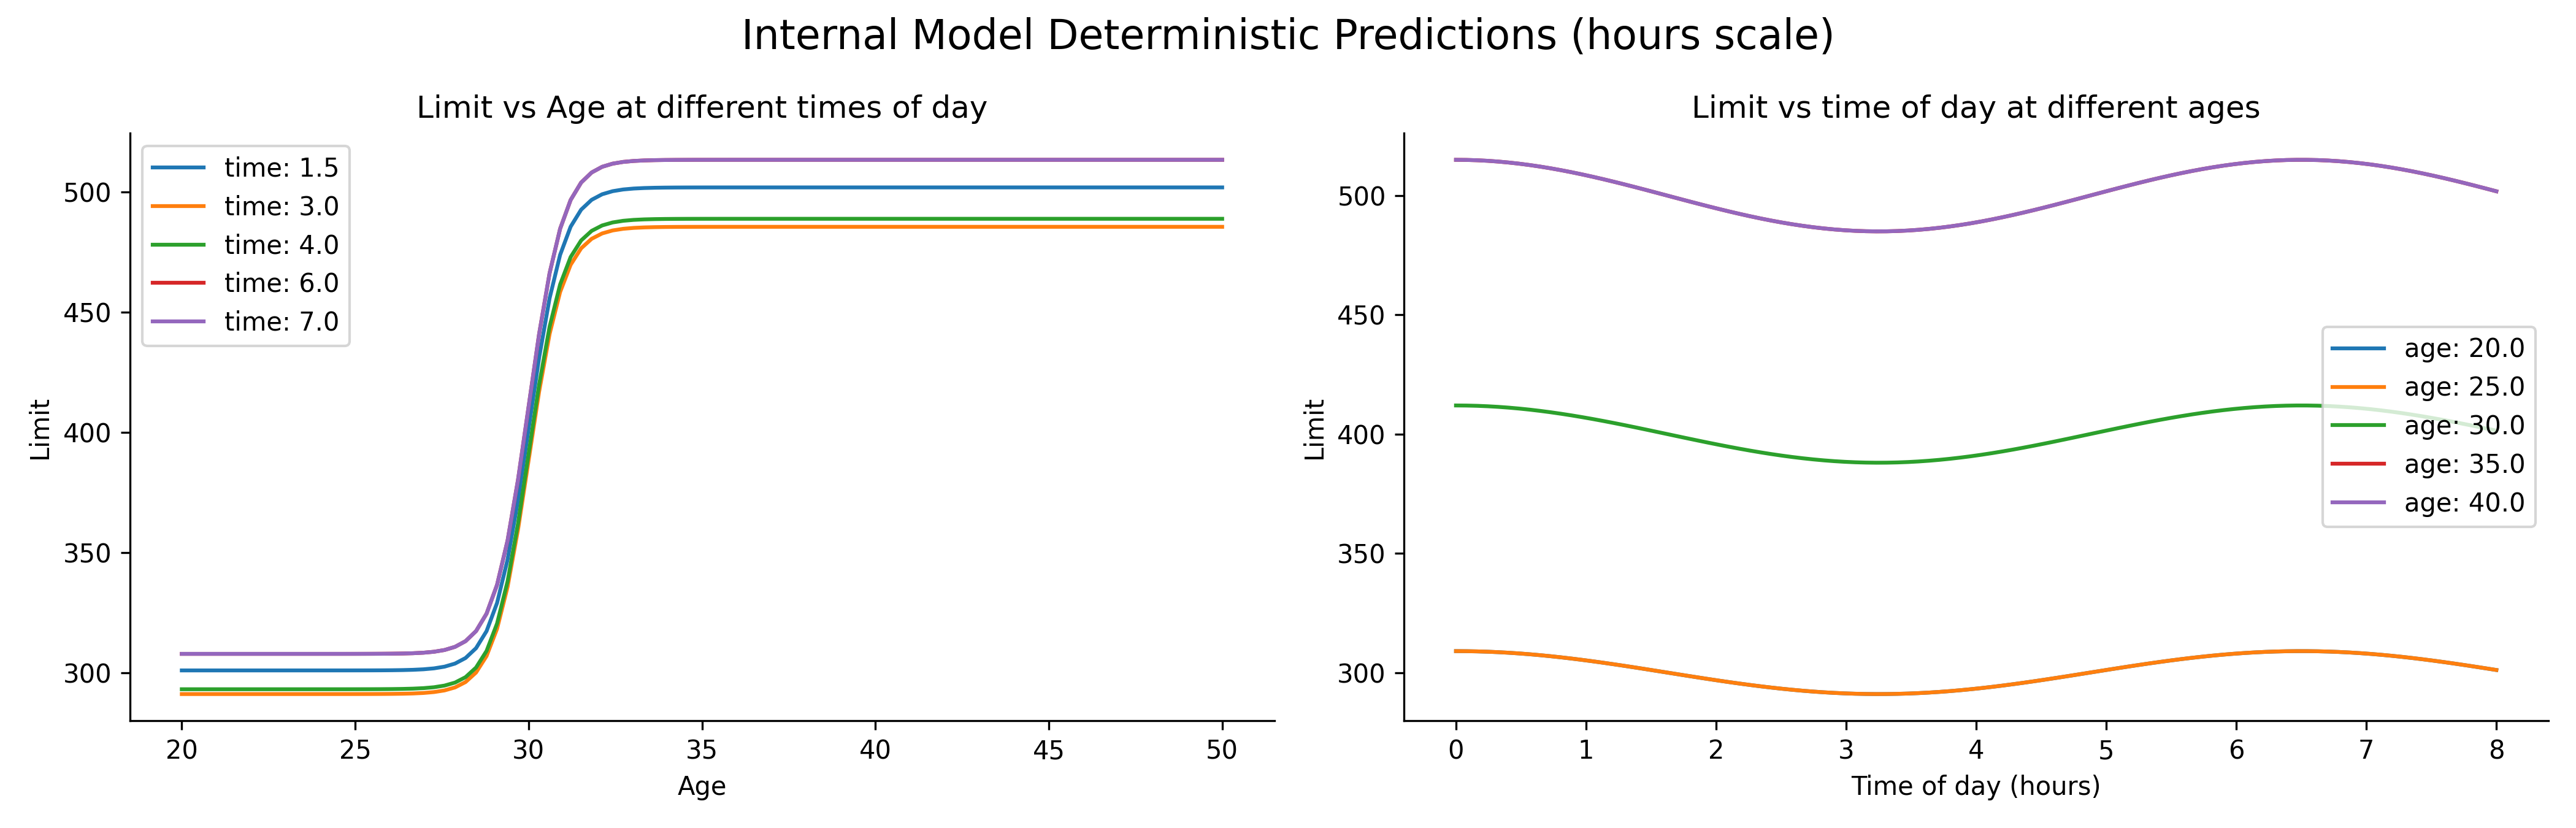

In [3]:
display(Image(filename="dce/internal_model_predictions.png"))

To compute PCI scores, we add a Bayesian layer. The second axis of difference between settings is the prior on age: we use two priors, which yield different push-forward distributions for the approved credit limit. Time of application is modeled by a single normal $\mathcal{N}(4,\,0.9)$ on the hour scale (correspondingly $\mathcal{N}(240,\,54)$ on the minute scale).

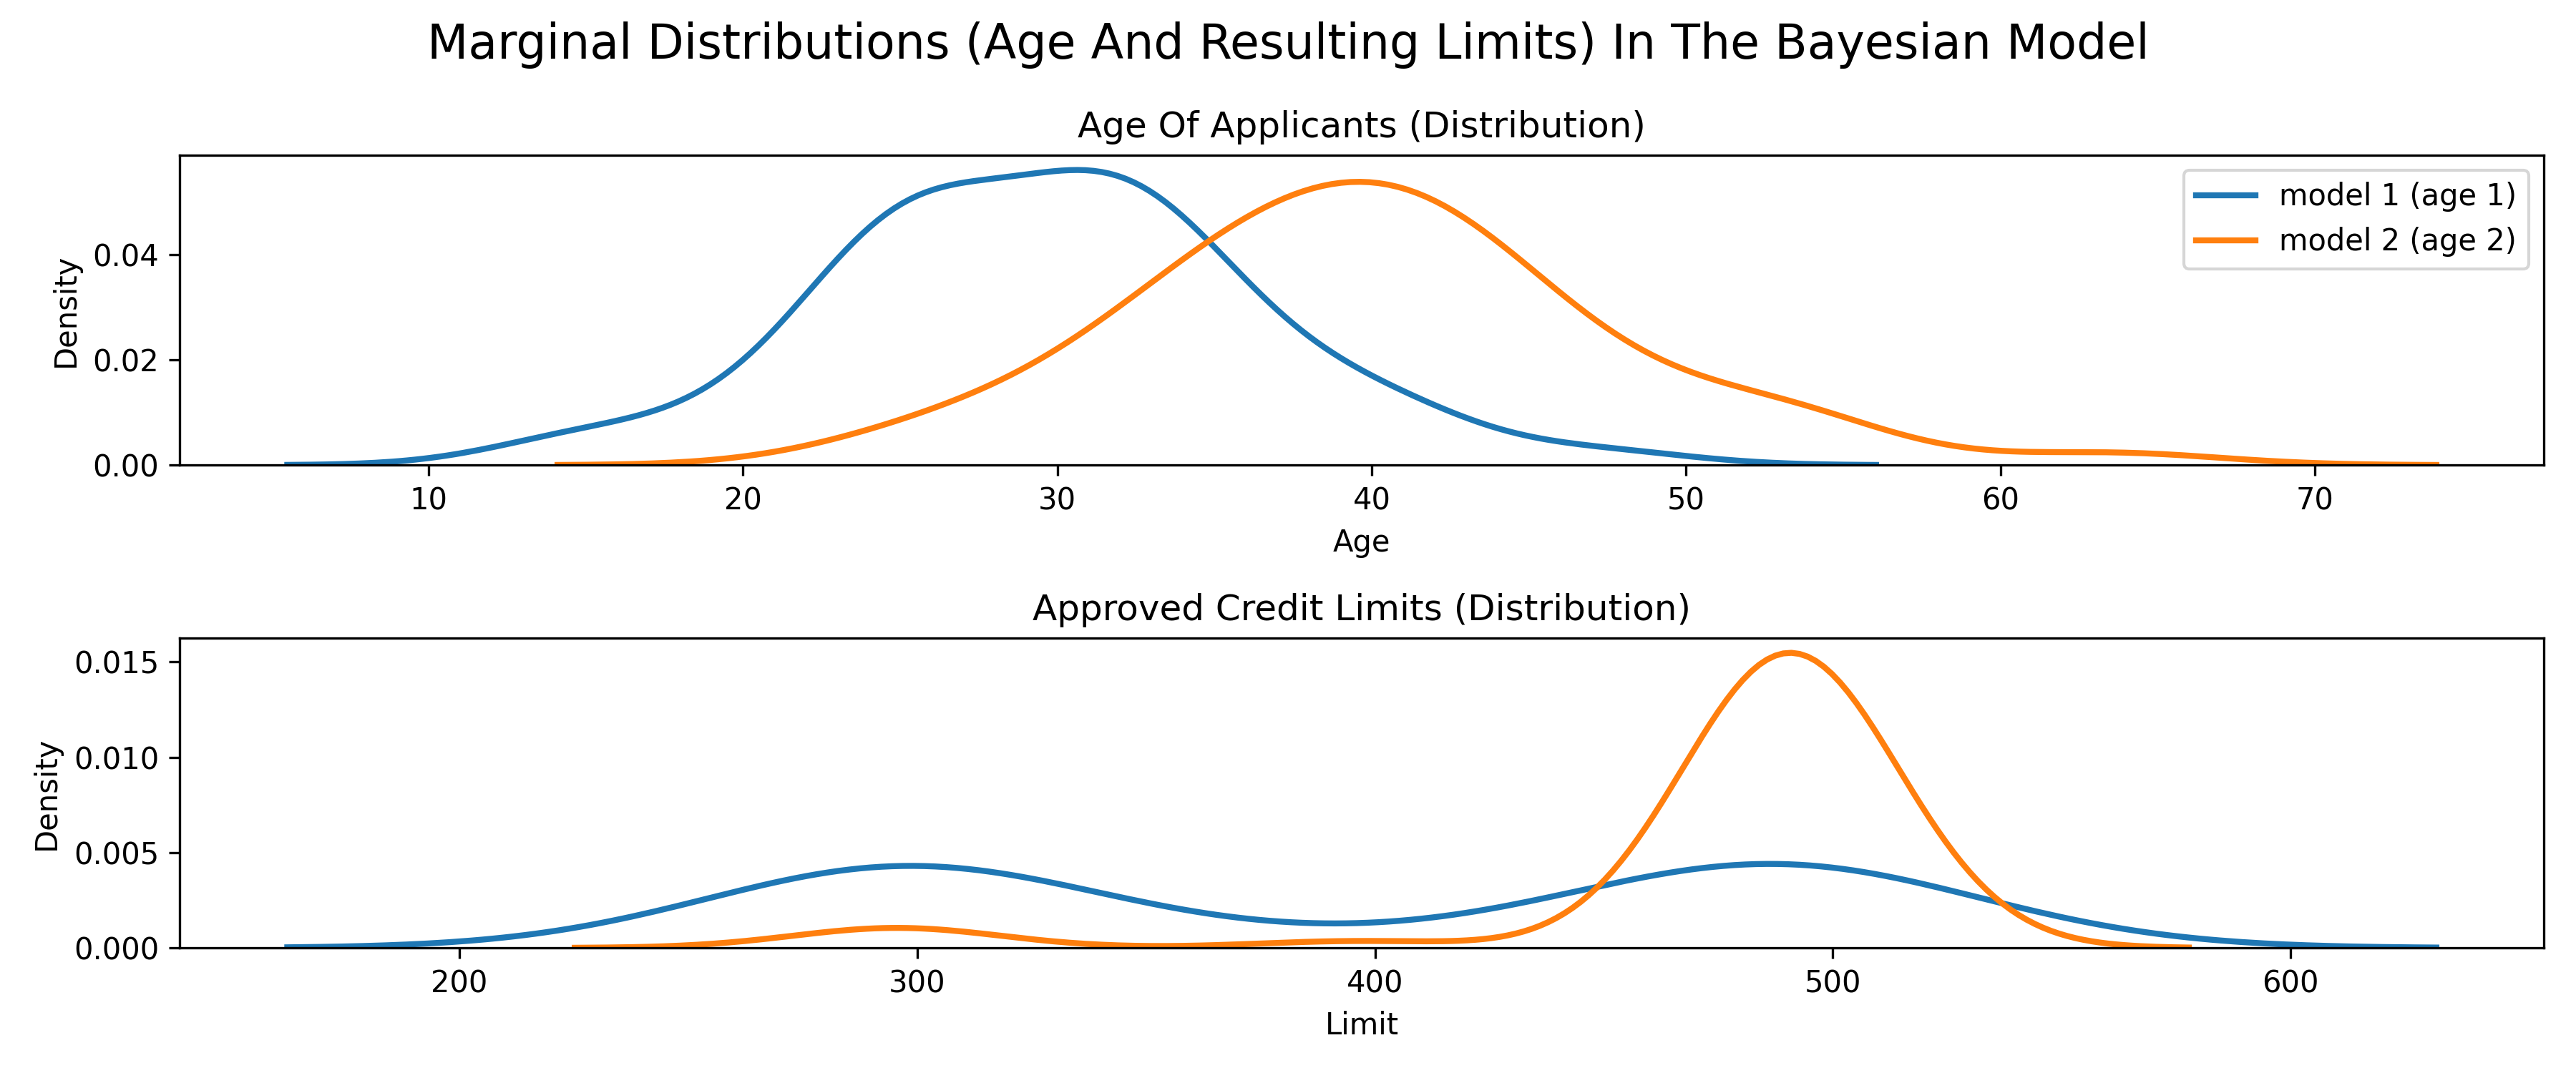

In [4]:
display(Image(filename="dce/marginal_distributions_age_hours.png"))

### Responsibility scores

We look at the results at two levels of granularity. First, we fix specific factual values for the inputs and sample from the expanded model, inspecting the resulting samples in the necessity and sufficiency worlds together with the point-wise scores. The total score is the mean of these point-wise scores. We do this conditional on each feature being intervened on in turn, first inspecting scores when age is the active antecedent, then the same for time of application.

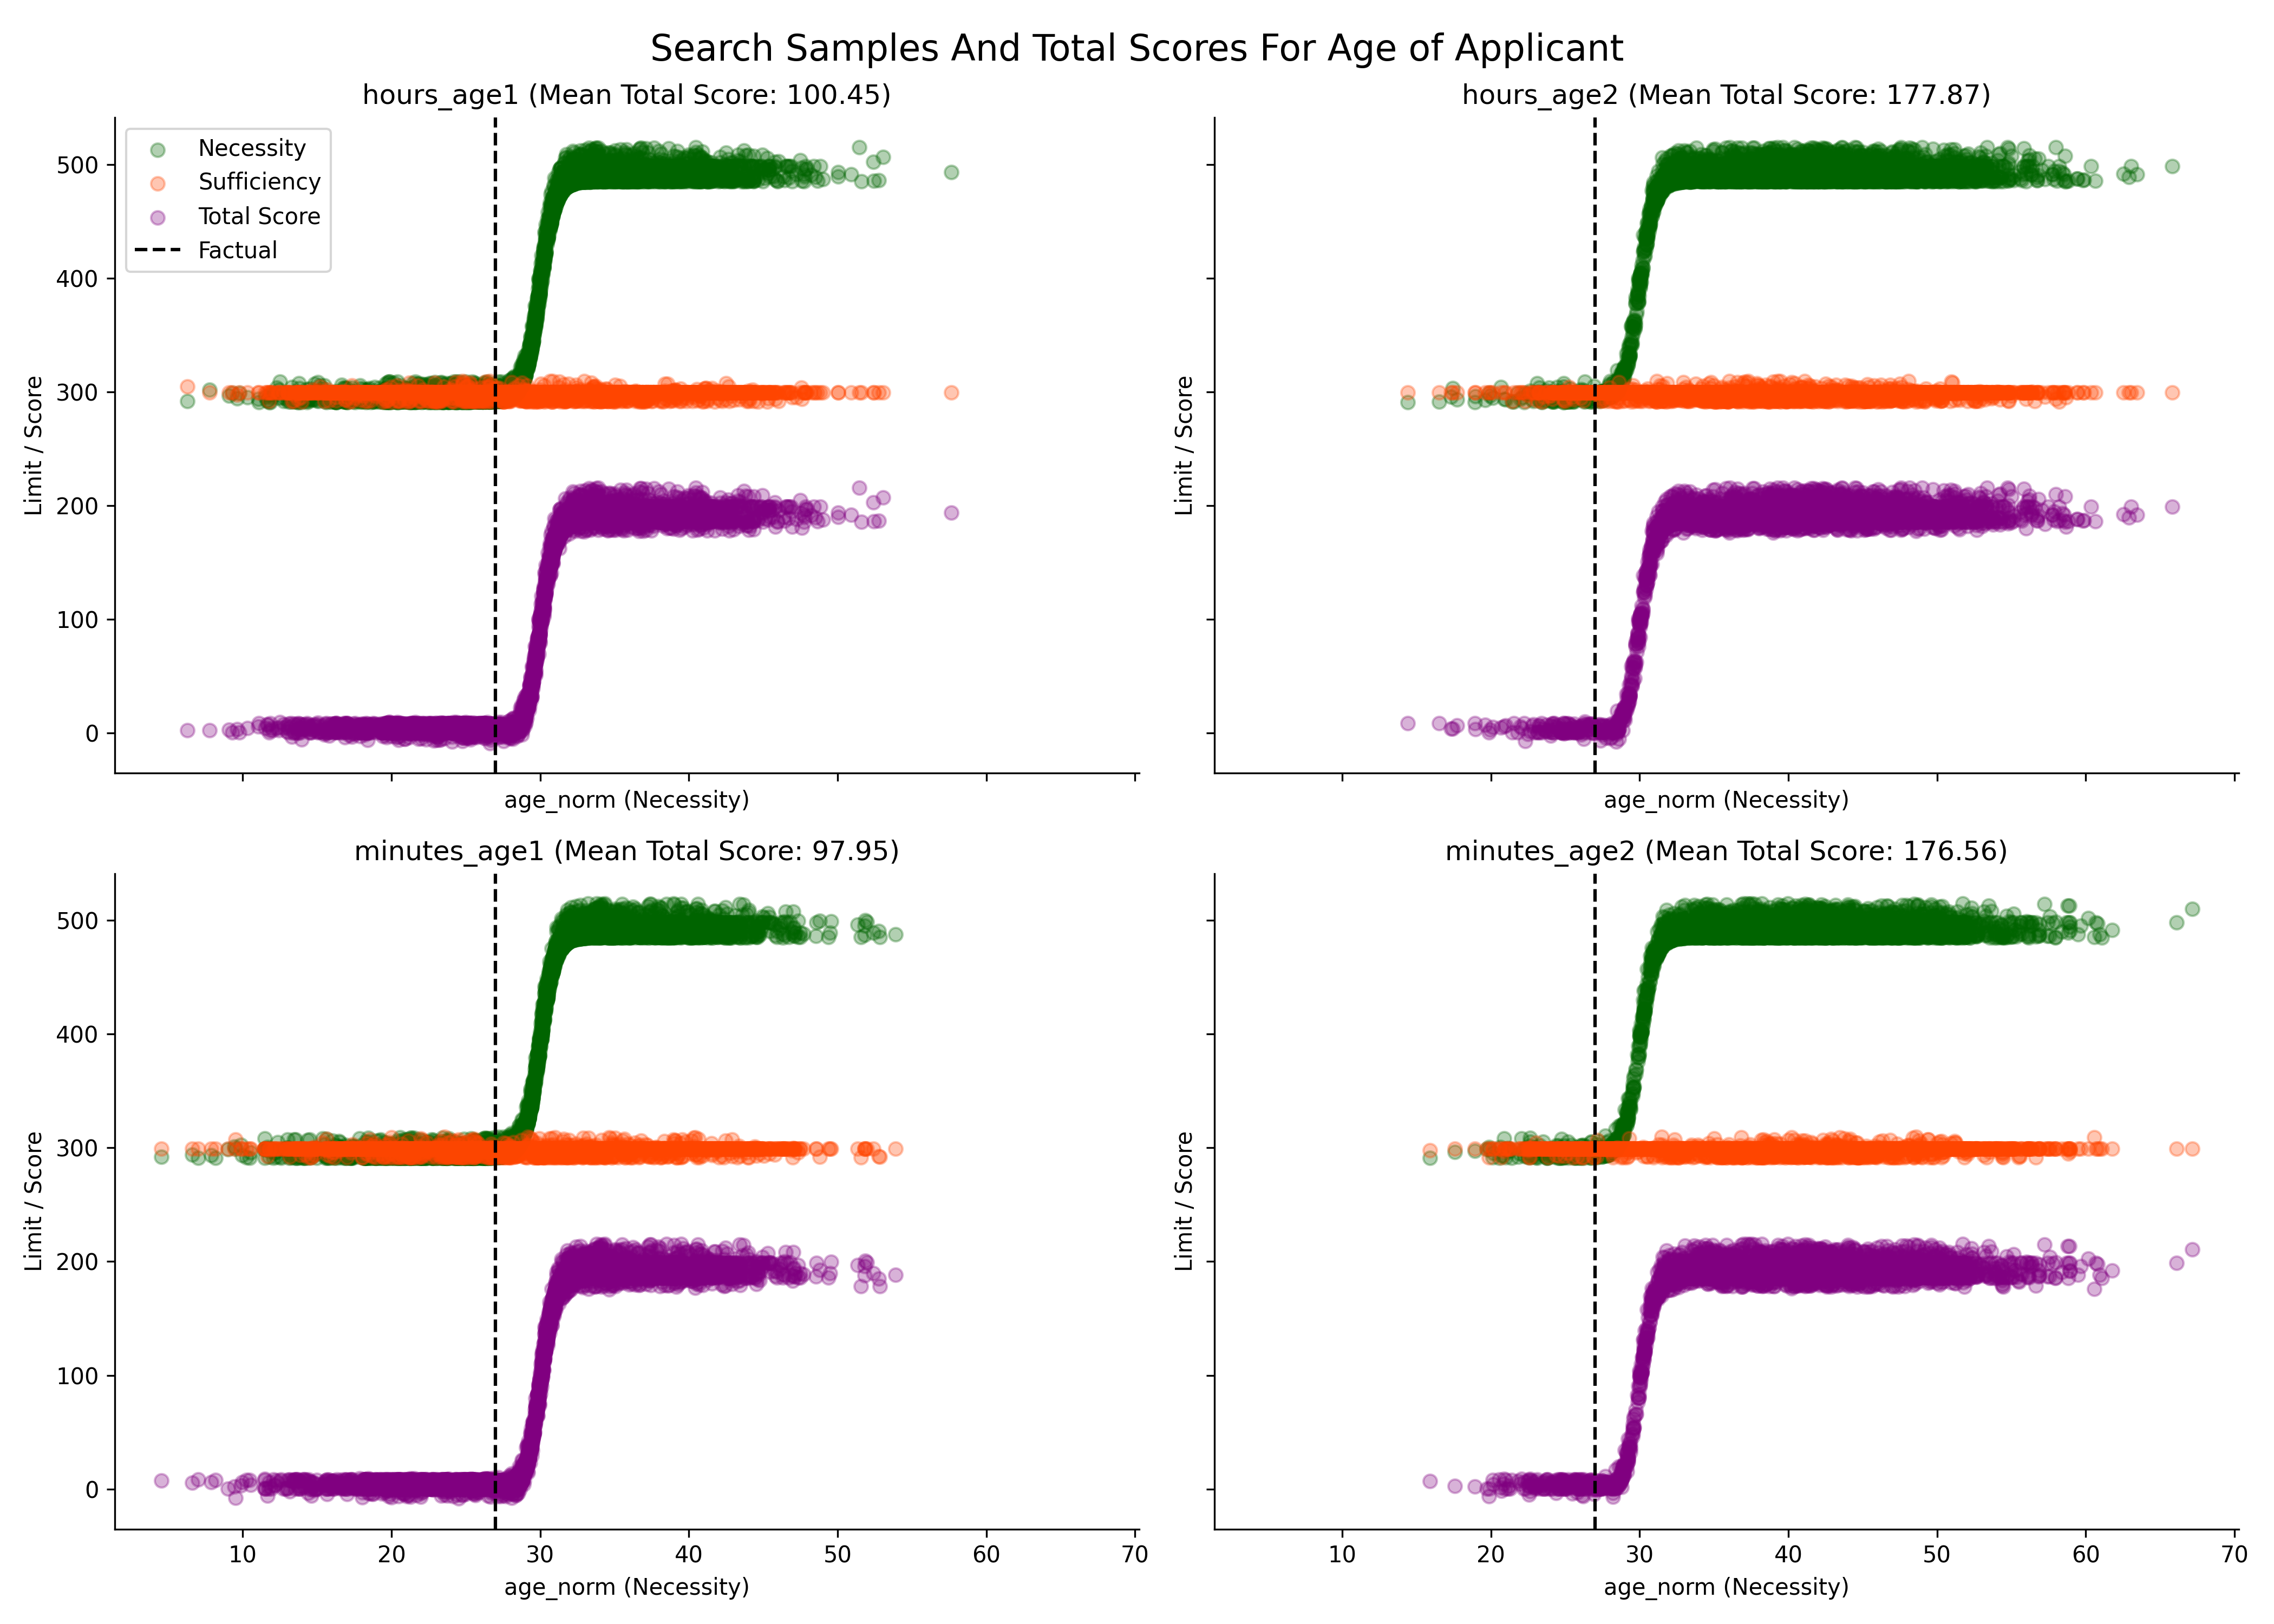

In [5]:
display(Image(filename="dce/search_samples_age_norm.png"))

In the sufficiency worlds the outcome does not change much, but it changes in the necessity world, and the change patterns roughly follow the deterministic curves plotted earlier. The difference between left and right reflects which prior was used for age: a more unusual factual age yields a higher score. The difference between rows (hour vs. minute scale) leaves the outcome distributions essentially unchanged.

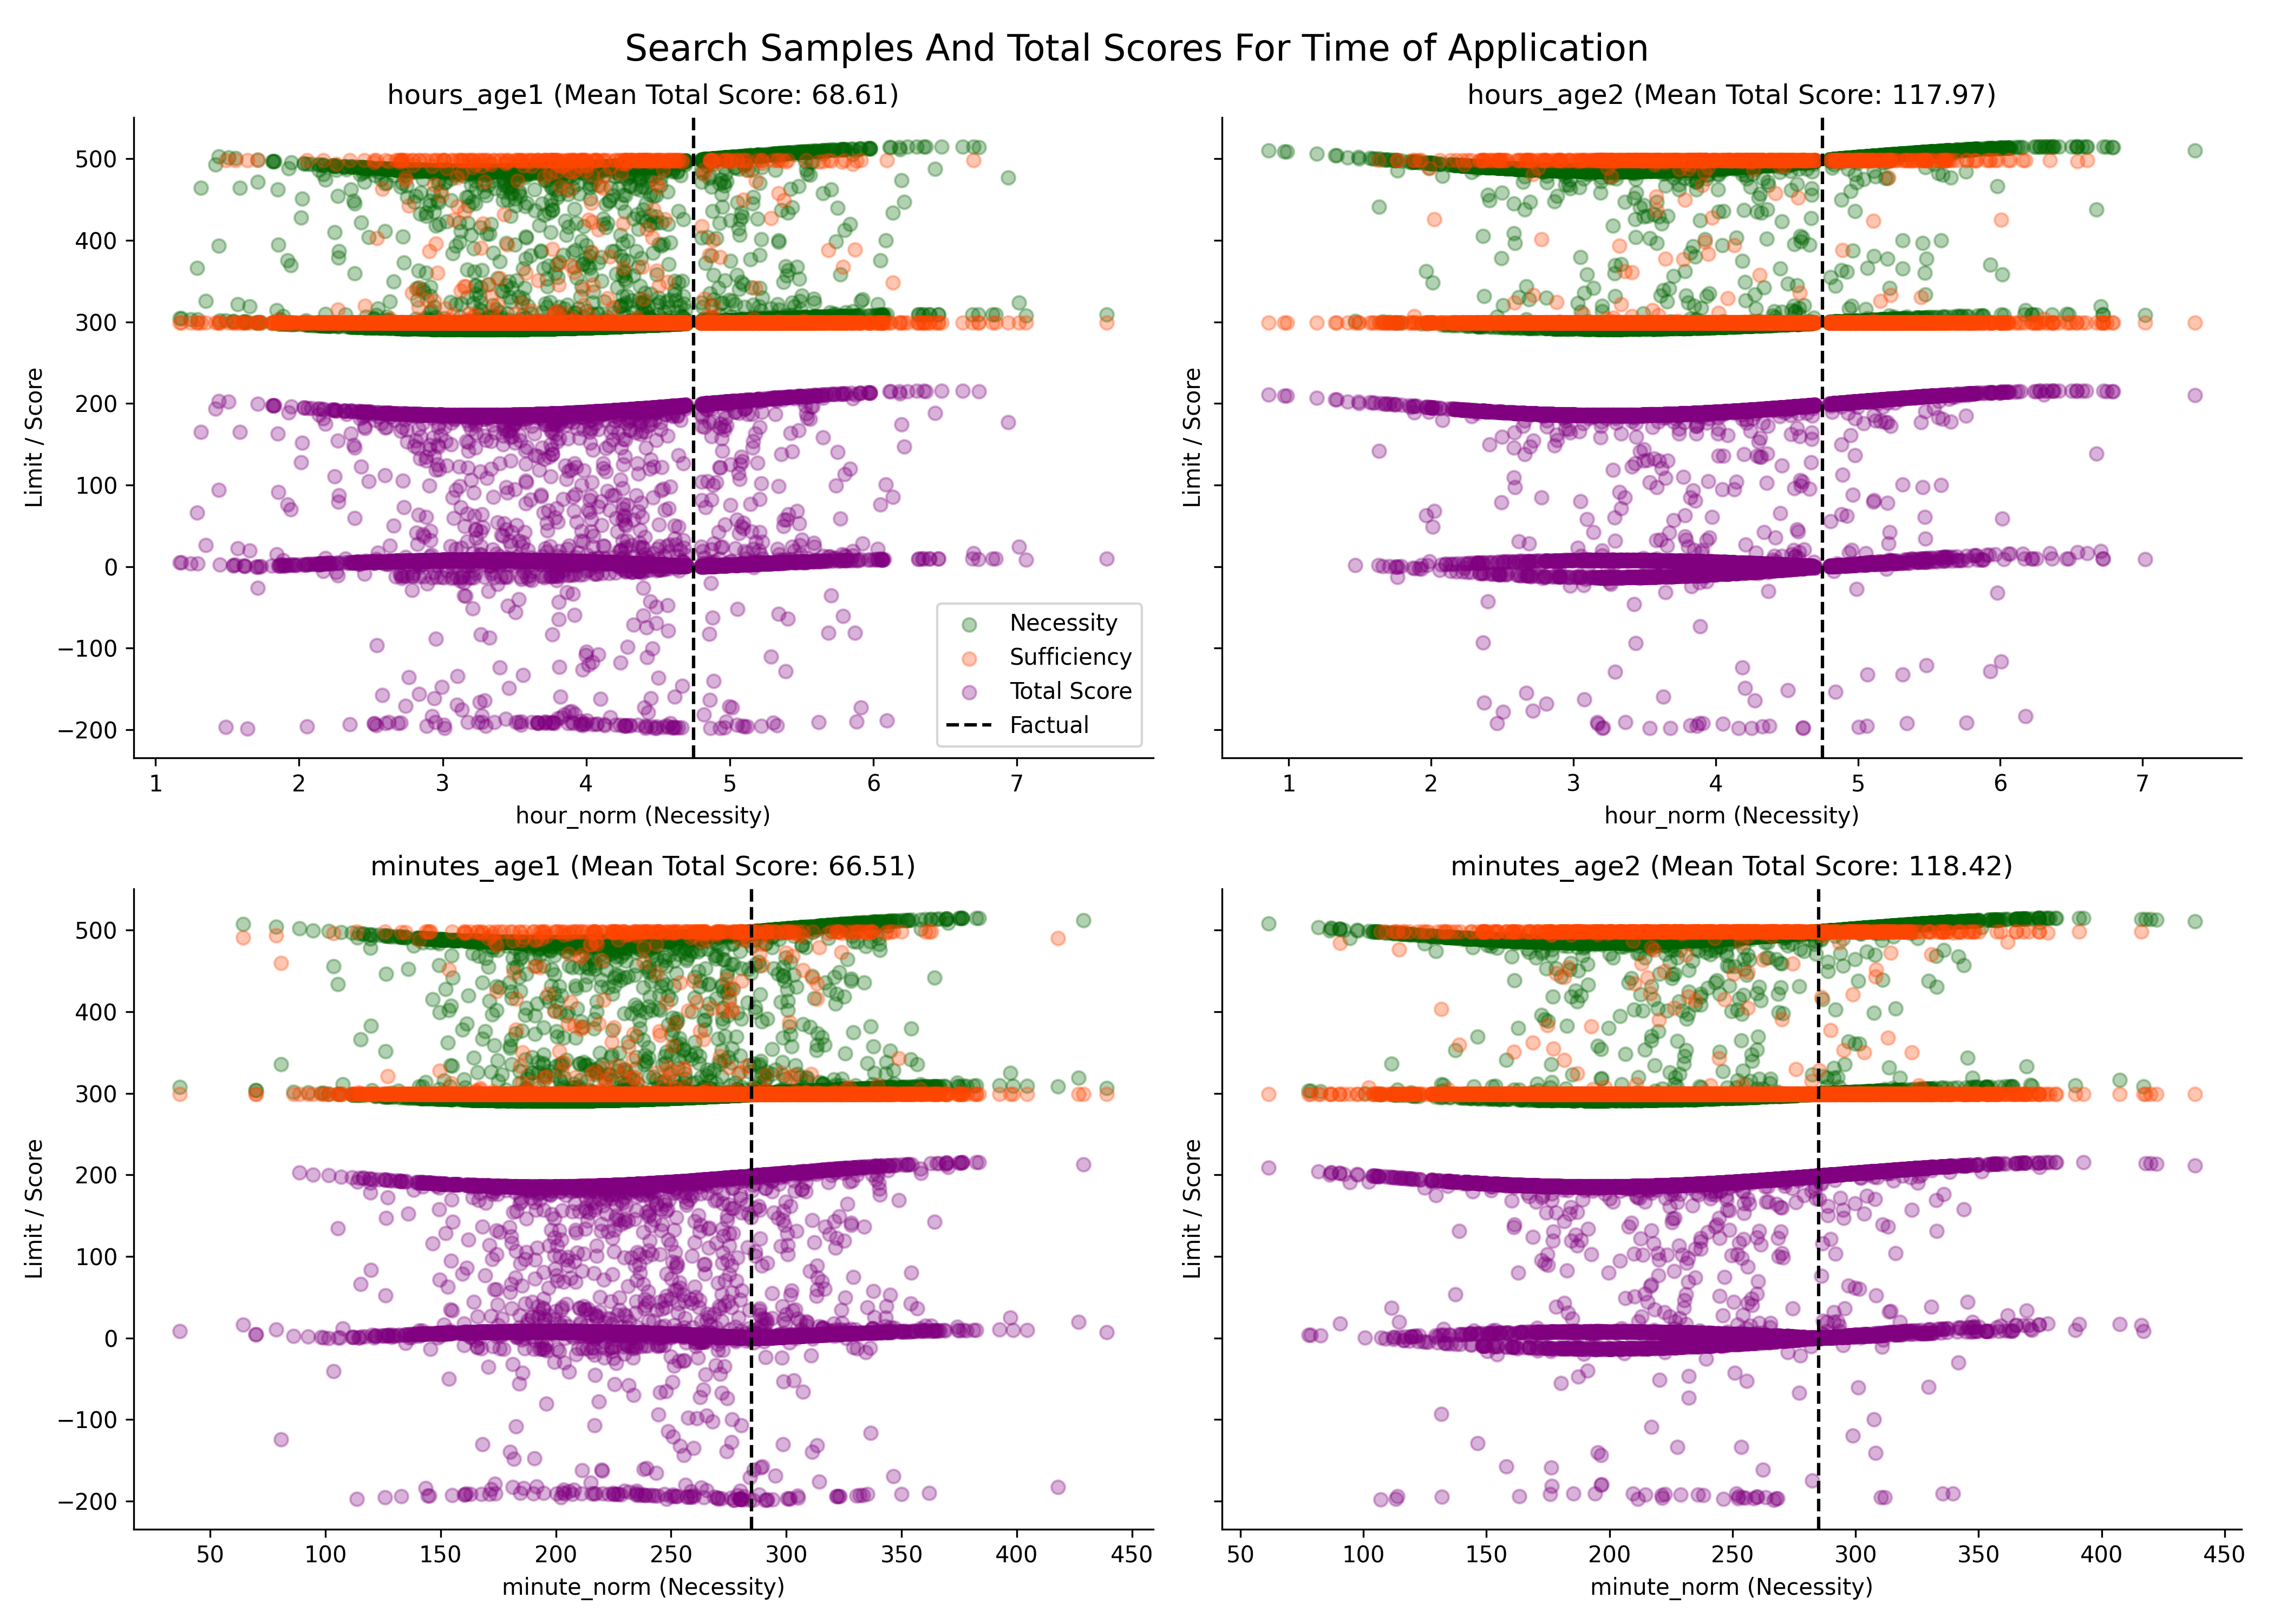

In [6]:
display(Image(filename="dce/search_samples_hour_norm.png"))

The plot layout is analogous. One difference: even in the sufficiency world the outcomes are sometimes quite different. This is because some sampling runs also resample age (for robustness), and age has a large impact, so time of application is not very sufficient for the credit limit on its own. The absolute changes in the outcome are also relatively small compared to those in the previous plot. Accordingly, the total scores are systematically lower for time of application than for age of applicant, which matches the intuition that age dominates.

Second, we compute responsibility scores across a range of inputs on a grid, and do the same for DCE. The PCI score is consistently higher for age, with individual values varying with how unusual the inputs are under the priors and what credit limits they produce in the necessity and sufficiency worlds.

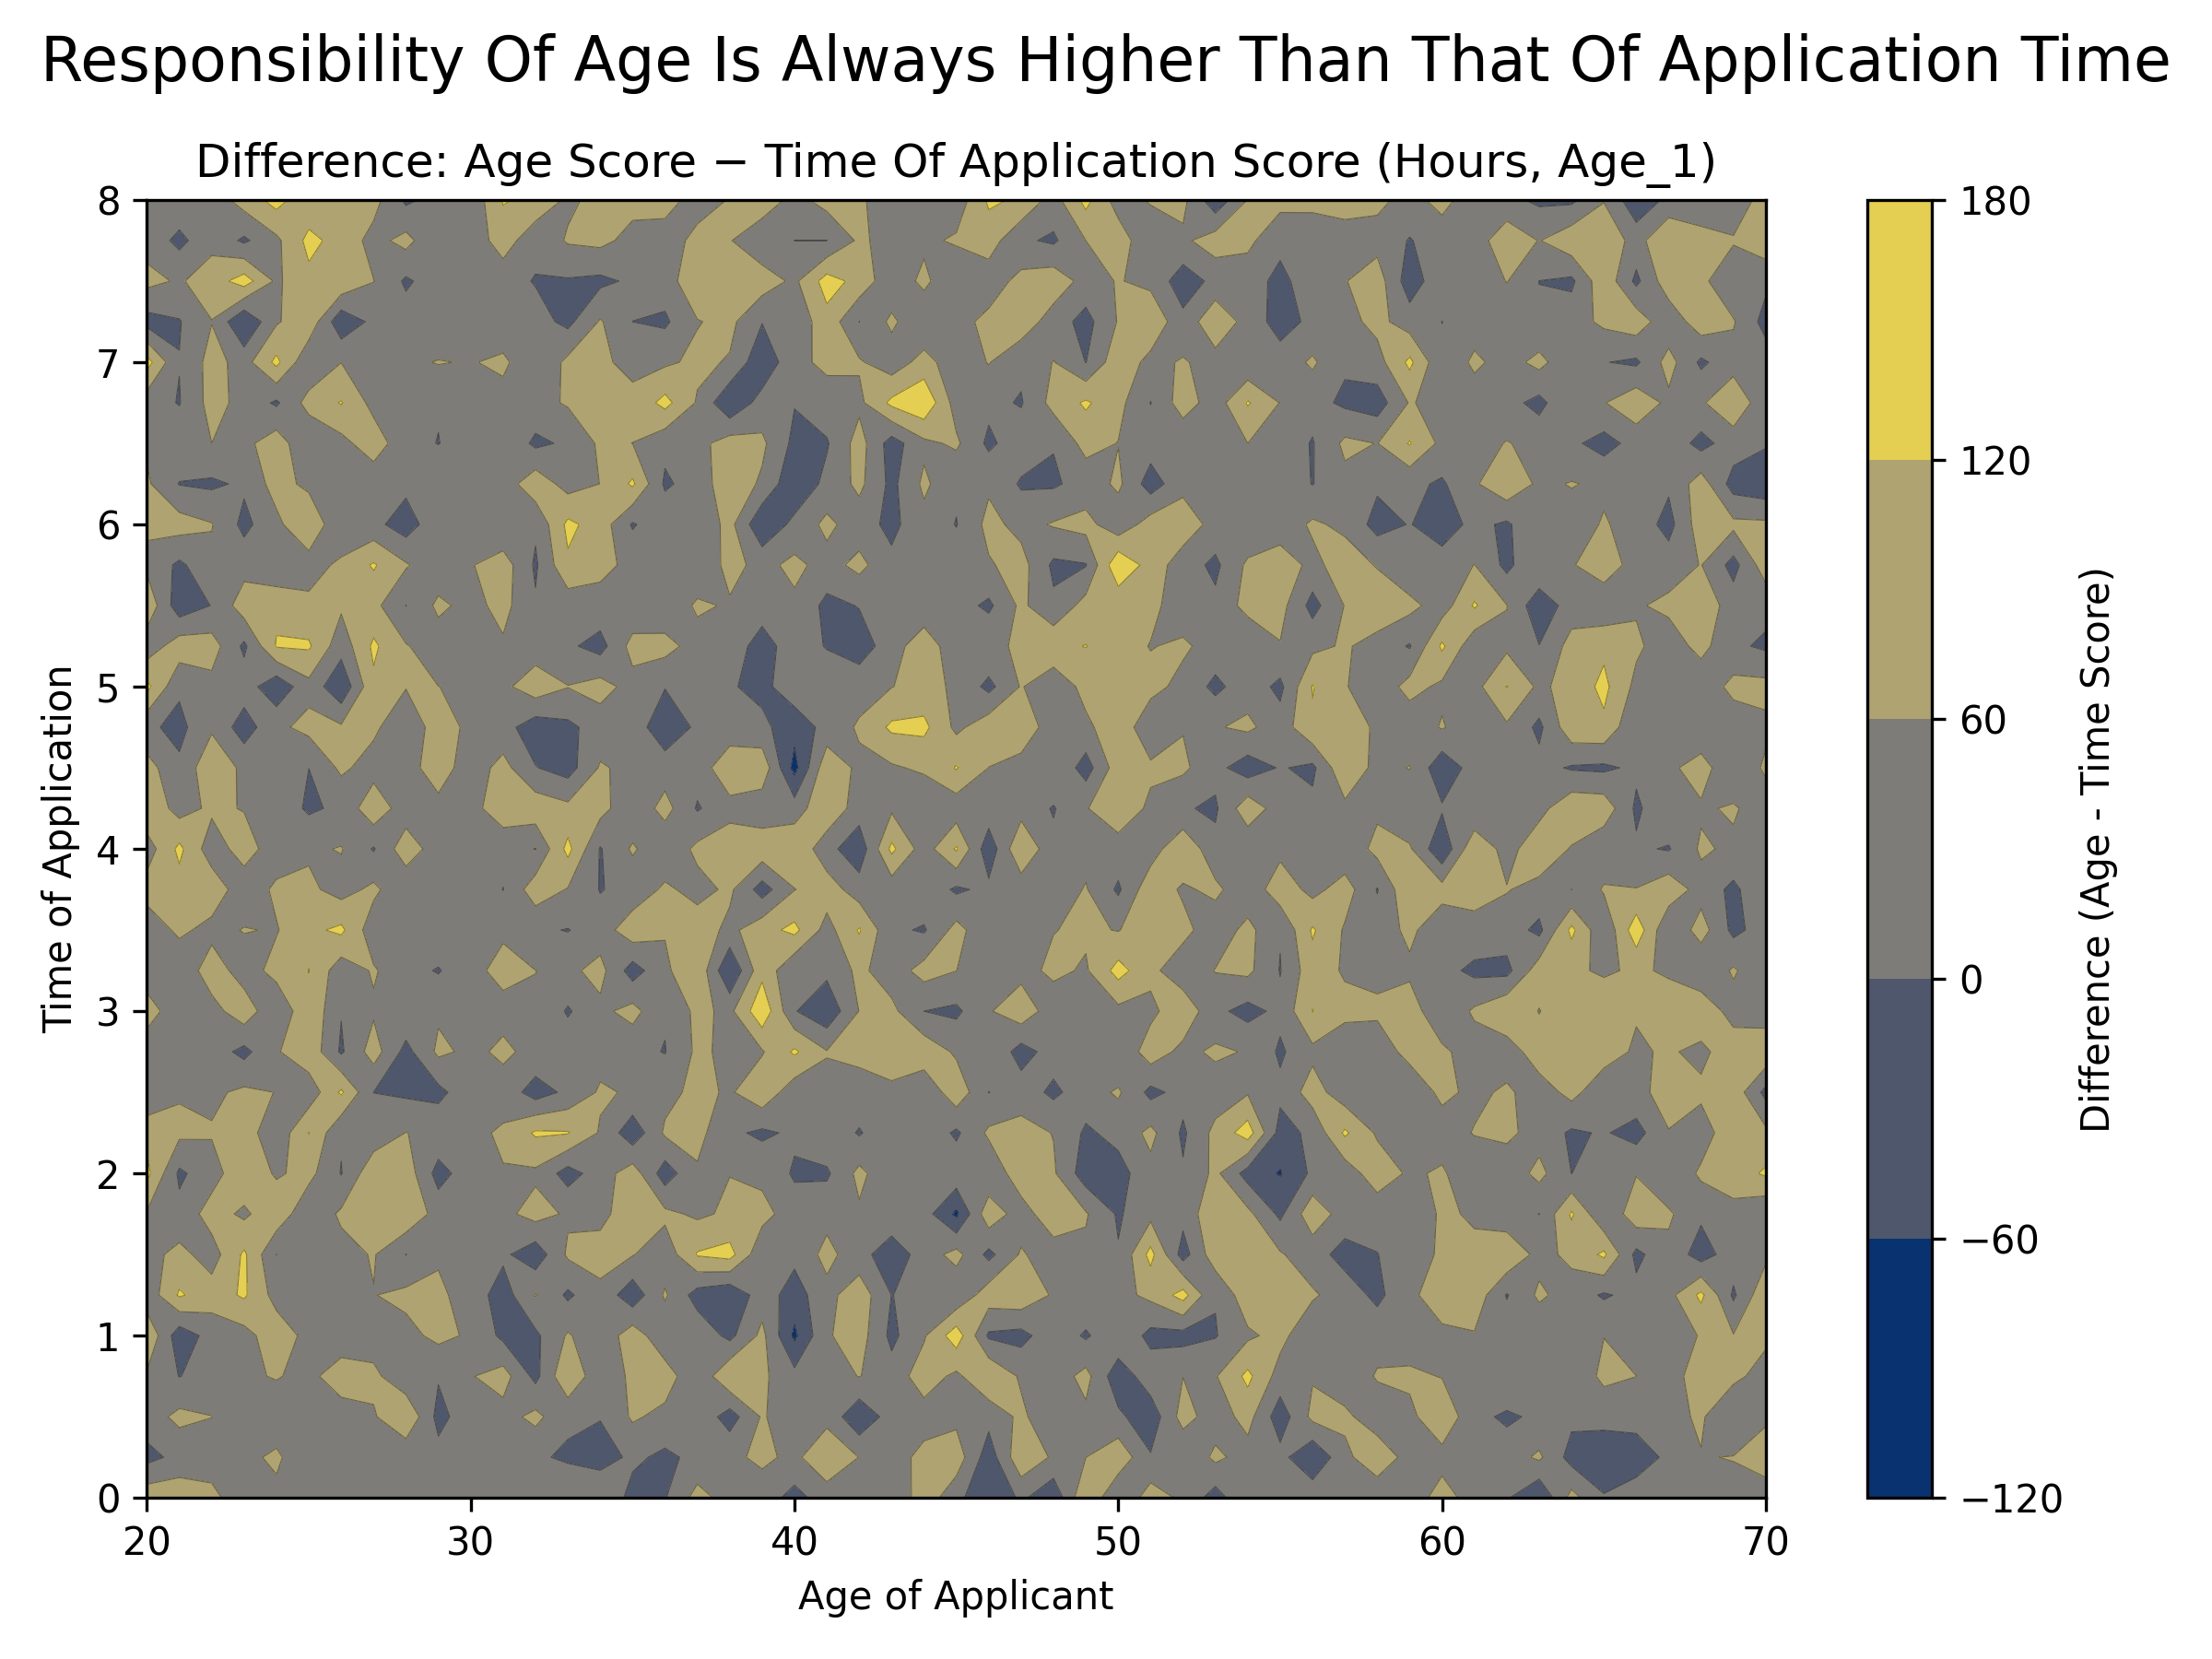

In [7]:
display(Image(filename="dce/contour_diff_hours_age_1.png"))

### Differential causal effects

By contrast, DCE scores are harder to interpret. On the hour scale, DCE for time of application is a sine wave whose absolute values exceed DCE for age over most of the grid, so DCE does not capture the intuition that age dominates time of application, since changes in time of application produce only minor outcome shifts while a change in age can have a much larger consequence.

Moreover, switching the scale from hours to minutes flattens DCE for time of application by roughly a factor of 60, illustrating that the score assigned to time of application is highly sensitive to input units.

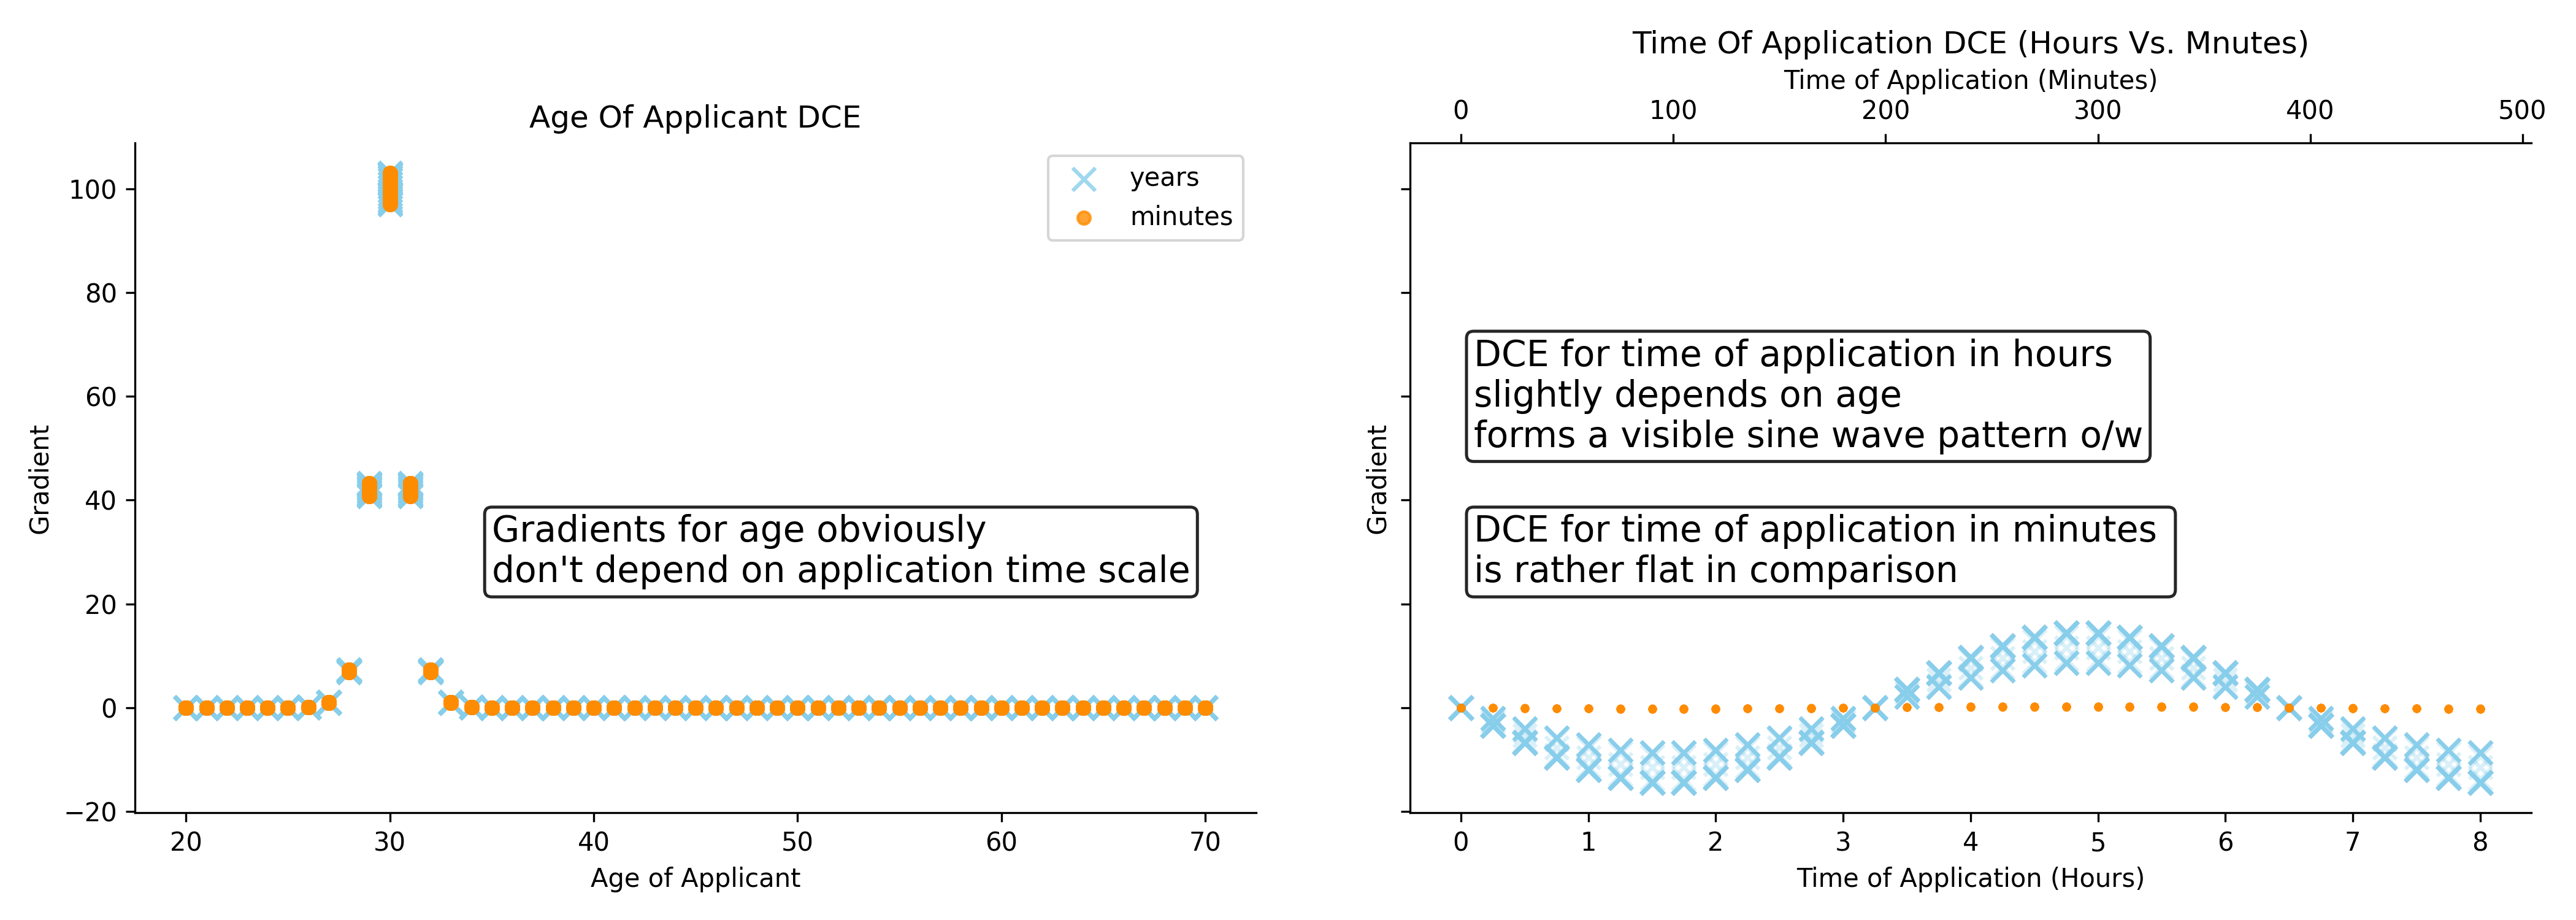

In [8]:
display(Image(filename="dce/dce_age_time_hours_minutes.png"))

## Code

The figures above were generated by the code that follows. The rest of the notebook is the full, runnable implementation, in the order the pieces are built: first the deterministic credit-limit model, then the Bayesian uncertainty layer, then the PCI search and scoring, and finally the DCE baseline. Readers who only want the story can stop here; readers who want to reproduce or modify the experiment can read on.


### Models

We start with the **deterministic component** $F$. `internal_model_hours` maps an applicant's age and time of day to a credit limit: the limit is a sigmoid in age (a sharp rise across a limited age range, scaled to roughly the \$300–\$500 range), multiplied by a small sinusoidal modulation in time of day. By construction age moves the limit by a large amount while time of day only nudges it. `internal_model_minutes` is the identical function with time expressed in minutes; the assertions in the next cell verify that the two agree up to the linear change of units, so any difference DCE reports between the scales is an artefact of units, not of the mechanism.


In [9]:
def internal_model_hours(age_norm: torch.Tensor, hour_norm: torch.Tensor):
    steepness = 2  # smaller -> more gradual, larger -> steeper
    amplitude = 0.03
    peak_hour = 0  # 10 AM peak

    age_scaled = (age_norm - 30) * steepness

    sigmoid_transform = transforms.SigmoidTransform()
    affine_transform = transforms.AffineTransform(300, 200)  # scale=200, loc=300
    transform = transforms.ComposeTransform([sigmoid_transform, affine_transform])

    limit_base = pyro.deterministic("limit_base", transform(age_scaled))

    multiplier = 1.0 + amplitude * torch.sin(
        2 * torch.pi * (hour_norm - peak_hour) / 6.5 + torch.pi / 2
    )
    # move to 0 if between 18 and 9

    limit = pyro.deterministic("limit", multiplier * limit_base)

    return limit


def internal_model_minutes(age_norm: torch.Tensor, minute_norm: torch.Tensor):
    steepness = 2  # smaller -> more gradual, larger -> steeper
    amplitude = 0.03
    peak_minute = 0  # 10 AM peak

    age_scaled = (age_norm - 30) * steepness

    sigmoid_transform = transforms.SigmoidTransform()
    affine_transform = transforms.AffineTransform(300, 200)  # scale=200, loc=300
    transform = transforms.ComposeTransform([sigmoid_transform, affine_transform])

    limit_base = pyro.deterministic("limit_base", transform(age_scaled))

    multiplier = 1.0 + amplitude * torch.sin(
        2 * torch.pi * (minute_norm - peak_minute) / 390 + torch.pi / 2
    )
    # move to 0 if between 18 and 9

    limit = pyro.deterministic("limit", multiplier * limit_base)

    return limit

/tmp/ipykernel_67483/1982015272.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  age_norm=torch.tensor(age_space), hour_norm=torch.tensor(time)


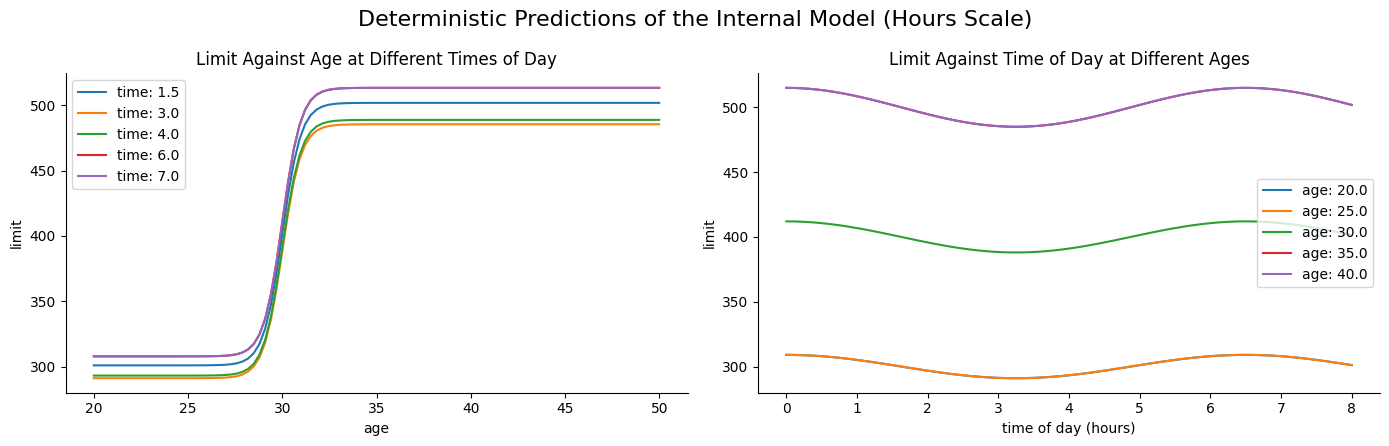

/tmp/ipykernel_67483/1982015272.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  age_norm=torch.tensor(age_space), minute_norm=torch.tensor(time)


In [10]:
# visualize impacts for the internal model (hours scale only; the minute scale is the
# same dependence modulo a linear reparameterisation, checked by the assertions below)

age_space = torch.linspace(20.0, 50.0, steps=100)
hour_space = torch.linspace(0, 8, steps=100)
minute_space = torch.linspace(0, 8 * 60, steps=100)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

hours = [1.5, 3.0, 4.0, 6.0, 7.0]
limits = {}
limits_age = {}
for time in hours:
    limits[time] = internal_model_hours(
        age_norm=torch.tensor(age_space), hour_norm=torch.tensor(time)
    ).numpy()
    axes[0].plot(age_space.numpy(), limits[time], label=f"time: {time}")

axes[0].set_xlabel("age")
axes[0].set_ylabel("limit")
axes[0].set_title("Limit Against Age at Different Times of Day")
axes[0].legend()
sns.despine(ax=axes[0])

ages = [20.0, 25.0, 30.0, 35.0, 40.0]
for _age in ages:
    limits_age[_age] = internal_model_hours(
        age_norm=torch.tensor(_age), hour_norm=hour_space
    ).numpy()
    axes[1].plot(hour_space.numpy(), limits_age[_age], label=f"age: {_age}")

axes[1].set_xlabel("time of day (hours)")
axes[1].set_ylabel("limit")
axes[1].set_title("Limit Against Time of Day at Different Ages")
axes[1].legend()
sns.despine(ax=axes[1])

plt.suptitle(
    "Deterministic Predictions of the Internal Model (Hours Scale)", fontsize=16
)
plt.tight_layout()
file_path = "dce/internal_model_predictions.png"
plt.savefig(file_path, dpi=300)
plt.show()

# Sanity check: the minute scale is the same dependence modulo a linear transform.
minutes = [h * 60 for h in hours]
limits_minutes = {}
limits_minutes_age = {}
for time in minutes:
    limits_minutes[time] = internal_model_minutes(
        age_norm=torch.tensor(age_space), minute_norm=torch.tensor(time)
    ).numpy()
for _age in ages:
    limits_minutes_age[_age] = internal_model_minutes(
        age_norm=torch.tensor(_age), minute_norm=minute_space
    ).numpy()
for key in limits.keys():
    np.testing.assert_allclose(limits[key], limits_minutes[key * 60], rtol=1e-5)
for key in limits_age.keys():
    np.testing.assert_allclose(limits_age[key], limits_minutes_age[key], rtol=1e-5)

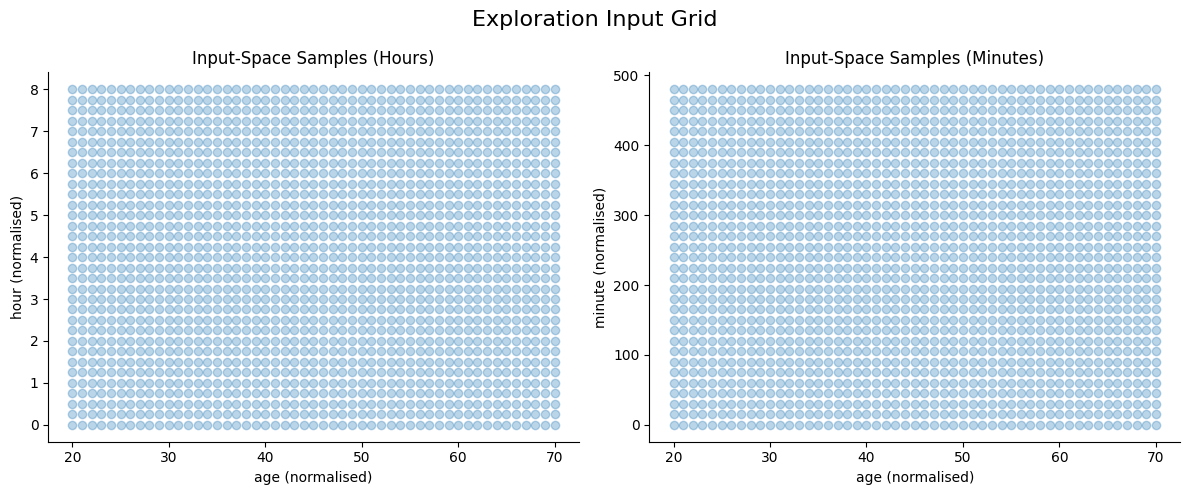

synth limits hours shape torch.Size([1683, 1, 1])
synth limits minutes shape torch.Size([1683, 1, 1])


In [11]:
# make synthetic data for future reference and
# build grids for further exploration

ages = torch.linspace(20.0, 70.0, steps=51)  # type: ignore
hours = torch.linspace(0.0, 8.0, steps=33)  # type: ignore
minutes = torch.linspace(0.0, 8.0 * 60, steps=33)  # type: ignore

# Build meshgrid
A, H = torch.meshgrid(ages, hours, indexing="ij")  # type: ignore
Am, M = torch.meshgrid(ages, minutes, indexing="ij")  # type: ignore

# Flatten and reshape to [N, 1, 1]
A_flat = A.reshape(-1, 1, 1)  # [51*33, 1, 1]
H_flat = H.reshape(-1, 1, 1)  # [51*33, 1, 1]

Am_flat = Am.reshape(-1, 1, 1)
M_flat = M.reshape(-1, 1, 1)

inputs_of_interest = {"age_norm": A_flat, "hour_norm": H_flat}
inputs_of_interest_minutes = {"age_norm": Am_flat, "minute_norm": M_flat}


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    inputs_of_interest["age_norm"].numpy().flatten(),
    inputs_of_interest["hour_norm"].numpy().flatten(),
    alpha=0.3,
)
axes[0].set_xlabel("age (normalised)")
axes[0].set_ylabel("hour (normalised)")
axes[0].set_title("Input-Space Samples (Hours)")
sns.despine(ax=axes[0])

axes[1].scatter(
    inputs_of_interest_minutes["age_norm"].numpy().flatten(),
    inputs_of_interest_minutes["minute_norm"].numpy().flatten(),
    alpha=0.3,
)
axes[1].set_xlabel("age (normalised)")
axes[1].set_ylabel("minute (normalised)")
axes[1].set_title("Input-Space Samples (Minutes)")
sns.despine(ax=axes[1])

plt.suptitle("Exploration Input Grid", fontsize=16)

plt.tight_layout()
plt.show()

# These are the evaluation grids
synthetic_limits_hours = internal_model_hours(**inputs_of_interest)
synthetic_limits_minutes = internal_model_minutes(**inputs_of_interest_minutes)


observations_dict_hours = {
    "continuous": {
        "limit": synthetic_limits_hours,
        "age_norm": inputs_of_interest["age_norm"],
        "hour_norm": inputs_of_interest["hour_norm"],
    },
    "categorical": {},
}

observations_dict_minutes = {
    "continuous": {
        "limit": synthetic_limits_minutes,
        "age_norm": inputs_of_interest_minutes["age_norm"],
        "minute_norm": inputs_of_interest_minutes["minute_norm"],
    },
    "categorical": {},
}


kwargs_iterable_hours = [
    {"observations_dict_hours": observations_dict_hours, "n_size": n_size}
]
kwargs_iterable_minutes = [
    {"observations_dict_minutes": observations_dict_minutes, "n_size": n_size}
]

print("synth limits hours shape", synthetic_limits_hours.shape)
print("synth limits minutes shape", synthetic_limits_minutes.shape)


n_size = 1

Next we add the Bayesian uncertainty layer. PCI scores are individual-level, but they are computed against the distributions the model assigns to the inputs, so we wrap the deterministic function in a Pyro model that places priors on the inputs: a normal on age (centred at $30$ or at $40$, our two priors) and a normal on time of application ($\mathcal{N}(4, 0.9)$ on the hour scale, $\mathcal{N}(240, 54)$ on the minute scale). `make_wrapped_model` is a factory that bakes in the chosen age mean and time unit, producing the four settings (hours/minutes $\times$ age-$30$/age-$40$). The cells that follow trace samples from each wrapped model and plot the resulting marginal distributions, so we can see how the prior choice reshapes the push-forward distribution of approved limits while the unit choice leaves it essentially unchanged.


In [12]:
# now add the uncertainty layer

AGE_MEAN_1 = 30.0
AGE_MEAN_2 = 40.0
AGE_STD = 7.0

HOUR_MEAN = 4.0
HOUR_STD = 0.9

MINUTE_MEAN = HOUR_MEAN * 60
MINUTE_STD = HOUR_STD * 60


def make_wrapped_model(
    internal_model,
    latent_name,
    latent_mean,
    latent_std,
    default_AGE_MEAN,
):
    """
    Creates a Pyro model wrapper with a configurable default AGE_MEAN.
    """

    def model(
        kwargs_iterable=[
            {"observations_dict": None, "n_size": n_size},
            dict(),
            dict(),
        ],
        AGE_MEAN=default_AGE_MEAN,  # <- default baked in here
    ):
        batch_size = kwargs_iterable[0]["n_size"]

        with pyro.plate("sample", size=batch_size, dim=-3):
            age_norm = pyro.sample("age_norm", dist.Normal(AGE_MEAN, AGE_STD))
            latent = pyro.sample(latent_name, dist.Normal(latent_mean, latent_std))

        return internal_model(age_norm=age_norm, **{latent_name: latent})

    return model


wrapped_hours_age1 = make_wrapped_model(
    internal_model=internal_model_hours,
    latent_name="hour_norm",
    latent_mean=HOUR_MEAN,
    latent_std=HOUR_STD,
    default_AGE_MEAN=AGE_MEAN_1,
)

wrapped_hours_age2 = make_wrapped_model(
    internal_model=internal_model_hours,
    latent_name="hour_norm",
    latent_mean=HOUR_MEAN,
    latent_std=HOUR_STD,
    default_AGE_MEAN=AGE_MEAN_2,
)

wrapped_minutes_age1 = make_wrapped_model(
    internal_model=internal_model_minutes,
    latent_name="minute_norm",
    latent_mean=MINUTE_MEAN,
    latent_std=MINUTE_STD,
    default_AGE_MEAN=AGE_MEAN_1,
)

wrapped_minutes_age2 = make_wrapped_model(
    internal_model=internal_model_minutes,
    latent_name="minute_norm",
    latent_mean=MINUTE_MEAN,
    latent_std=MINUTE_STD,
    default_AGE_MEAN=AGE_MEAN_2,
)

In [13]:
# run the wrapped models with tracing
# take a look at the uncertainties


def run_model_with_trace(model, kwargs_iterable, sample_size):
    with pyro.plate("samples", size=sample_size, dim=-4):
        with pyro.poutine.trace() as tr:
            result = model(kwargs_iterable=kwargs_iterable)
    return tr, result


models = {
    "hours_age1": wrapped_hours_age1,
    "hours_age2": wrapped_hours_age2,
    "minutes_age1": wrapped_minutes_age1,
    "minutes_age2": wrapped_minutes_age2,
}

kwargs_map = {
    "hours_age1": kwargs_iterable_hours,
    "hours_age2": kwargs_iterable_hours,
    "minutes_age1": kwargs_iterable_minutes,
    "minutes_age2": kwargs_iterable_minutes,
}


traces = {}
results = {}

for name, model in models.items():
    tr, res = run_model_with_trace(model, kwargs_map[name], sample_size)
    traces[name] = tr
    results[name] = res

In [14]:
def plot_traces_hours_minutes_kde(
    traces_hours: dict,
    traces_minutes: dict,
    keys_hours=["age_norm", "hour_norm", "limit"],
    keys_minutes=["age_norm", "minute_norm", "limit"],
):
    """
    Same as your histogram function, but plots KDE density curves instead.
    """

    fig, axes = plt.subplots(2, len(keys_hours), figsize=(16, 8))

    # ----- ROW 0: HOURS -----
    for col, key in enumerate(keys_hours):
        ax = axes[0, col]
        for label, trace in traces_hours.items():
            values = trace.trace.nodes[key]["value"].detach().cpu().numpy().flatten()

            sns.kdeplot(
                values,
                ax=ax,
                label=f"{label}",
                linewidth=2,
            )

        ax.set_title(f"{key} (Hours)")
        ax.set_xlabel(key)
        ax.set_ylabel("density")
        ax.legend()
        sns.despine(ax=ax)

    # ----- ROW 1: MINUTES -----
    for col, key in enumerate(keys_minutes):
        ax = axes[1, col]
        for label, trace in traces_minutes.items():
            values = trace.trace.nodes[key]["value"].detach().cpu().numpy().flatten()

            sns.kdeplot(
                values,
                ax=ax,
                label=f"{label}",
                linewidth=2,
            )

        ax.set_title(f"{key} (Minutes)")
        ax.set_xlabel(key)
        ax.set_ylabel("density")
        ax.legend()
        sns.despine(ax=ax)

    plt.suptitle("Marginal Distributions in the Bayesian Model", fontsize=16)
    plt.tight_layout()
    plt.show()

In [15]:
traces["hours_age2"].trace.nodes.keys()

odict_keys(['sample', 'age_norm', 'hour_norm', 'limit_base', 'limit'])

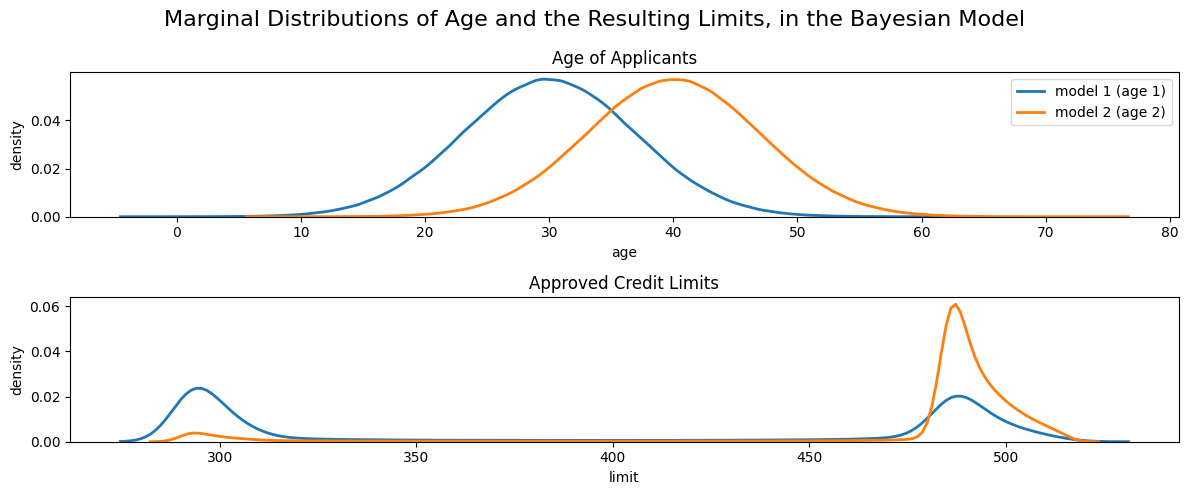

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5))  # <-- create one axes


traces_hours = {
    "model 1 (age 1)": traces["hours_age1"],
    "model 2 (age 2)": traces["hours_age2"],
}


for label, trace in traces_hours.items():
    values = trace.trace.nodes["age_norm"]["value"].detach().cpu().numpy().flatten()

    sns.kdeplot(
        values,
        ax=axes[0],
        label=f"{label}",
        linewidth=2,
    )

axes[0].set_title("Age of Applicants")
axes[0].set_xlabel("age")
axes[0].set_ylabel("density")
axes[0].legend()

for label, trace in traces_hours.items():
    values = trace.trace.nodes["limit"]["value"].detach().cpu().numpy().flatten()

    sns.kdeplot(
        values,
        ax=axes[1],
        label=f"{label}",
        linewidth=2,
    )

axes[1].set_title("Approved Credit Limits")
axes[1].set_xlabel("limit")
axes[1].set_ylabel("density")


plt.suptitle(
    "Marginal Distributions of Age and the Resulting Limits, in the Bayesian Model",
    fontsize=16,
)
plt.tight_layout()
fig_path = "dce/marginal_distributions_age_hours.png"
plt.savefig(fig_path, dpi=300)
plt.show()

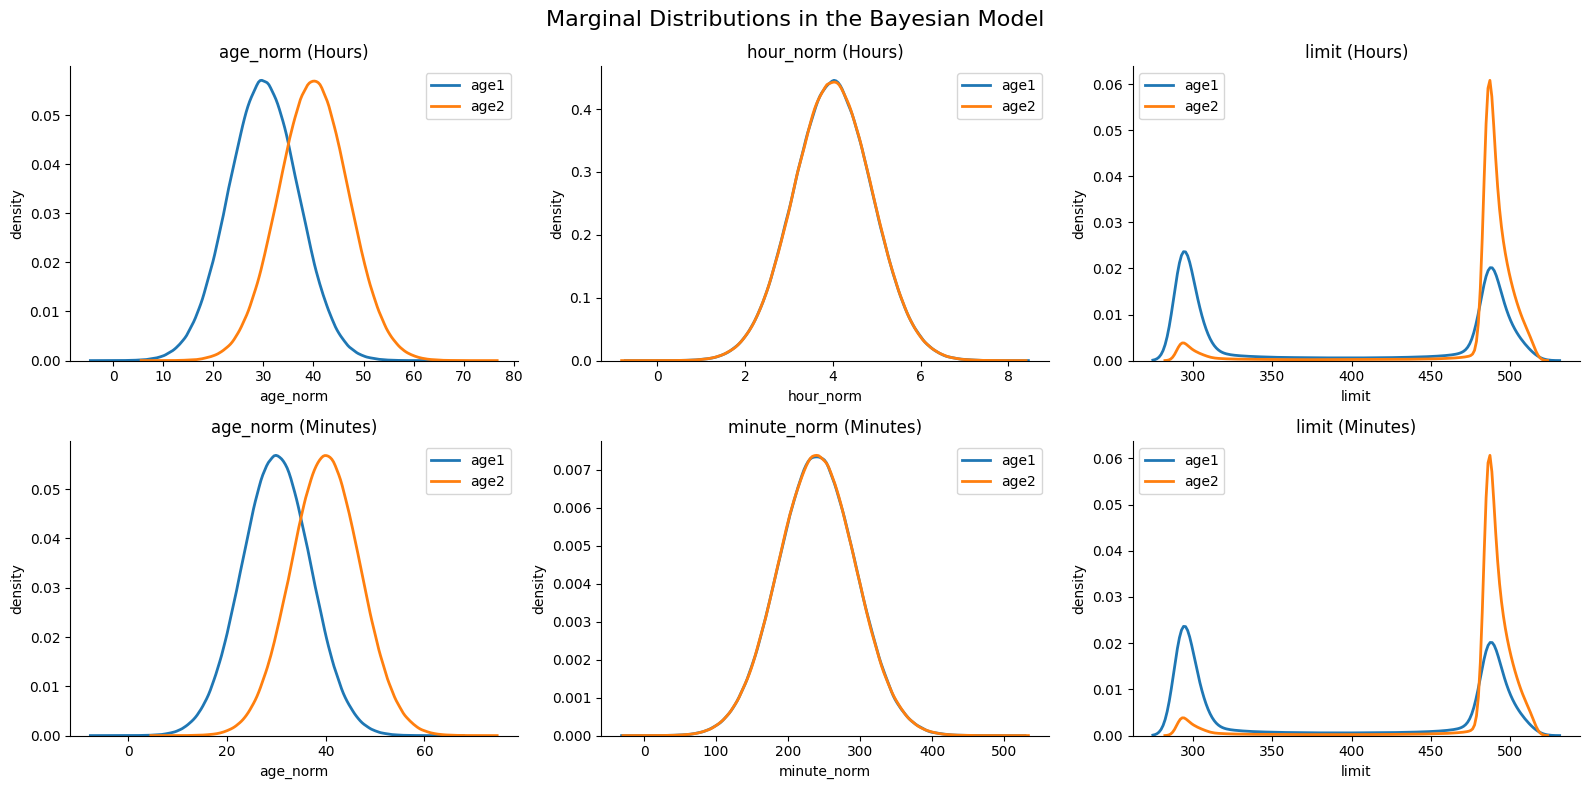

In [17]:
traces_hours = {
    "age1": traces["hours_age1"],
    "age2": traces["hours_age2"],
}

traces_minutes = {
    "age1": traces["minutes_age1"],
    "age2": traces["minutes_age2"],
}

plot_traces_hours_minutes_kde(traces_hours, traces_minutes)

### PCI search

With the probabilistic model in place we can run the PCI search. The idea behind PCI (Probabilistic Causal Impact) is to score how responsible a candidate cause, the *suspect*, was for the observed outcome by comparing two counterfactual regimes:

- the necessity world, where we ask what the outcome would have been had the suspect taken a *different* value (would the limit have changed if this applicant's age had been otherwise?), and
- the sufficiency world, where we *hold the suspect at its factual value* and let other things vary, asking whether the suspect alone is enough to pin the outcome down.

`SearchableModel` wraps each probabilistic model and declares which variables are *sites of interest* and which are *suspects* (here, age and time of application). `ThinSearchSampler` then draws Monte Carlo samples of the necessity and sufficiency worlds. We run this once per setting and cache the (relatively expensive) search results to `search_results.pkl`. Nothing here requires the model to be differentiable, only that we can sample from it, the first of the three differences with DCE flagged in the overview.


In [18]:
def make_searchable_model(
    wrapped_model,
    sites_of_interest,
    suspects,
    outcome_variable="limit",
):
    return SearchableModel(
        structured_model=wrapped_model,
        sites_of_interest=sites_of_interest,
        suspects=suspects,
        outcome_variable=outcome_variable,
    )


model_configs = {
    "hours_age1": {
        "wrapped": wrapped_hours_age1,
        "sites": ["age_norm", "hour_norm"],
        "suspects": ["age_norm", "hour_norm"],
    },
    "hours_age2": {
        "wrapped": wrapped_hours_age2,
        "sites": ["age_norm", "hour_norm"],
        "suspects": ["age_norm", "hour_norm"],
    },
    "minutes_age1": {
        "wrapped": wrapped_minutes_age1,
        "sites": ["age_norm", "minute_norm"],
        "suspects": ["age_norm", "minute_norm"],
    },
    "minutes_age2": {
        "wrapped": wrapped_minutes_age2,
        "sites": ["age_norm", "minute_norm"],
        "suspects": ["age_norm", "minute_norm"],
    },
}

obs_map = {
    "hours_age1": observations_dict_hours,
    "hours_age2": observations_dict_hours,
    "minutes_age1": observations_dict_minutes,
    "minutes_age2": observations_dict_minutes,
}

searchable_models = {}

for name, cfg in model_configs.items():
    searchable_models[name] = make_searchable_model(
        wrapped_model=cfg["wrapped"],
        sites_of_interest=cfg["sites"],
        suspects=cfg["suspects"],
        outcome_variable="limit",
    )

samplers = {}

for name, searchable in searchable_models.items():
    samplers[name] = ThinSearchSampler(
        structured_model=searchable,
        conditioned_alternatives=True,
        factual_exclusion=True,
    )


cache_file = "search_results.pkl"

# Load cache if it exists
if not smoke_test and os.path.exists(cache_file):
    with open(cache_file, "rb") as f:
        search_results = pickle.load(f)
else:
    search_results = {}


for name, sampler in samplers.items():
    if name not in search_results:
        print(f"Sampling for {name}...")
        search_results[name] = sampler.sample(
            obs_map[name], num_samples=num_search_samples
        )
    else:
        print(f"Using cached result for {name}")

# Save updated cache
if not smoke_test:
    with open(cache_file, "wb") as f:  # type: ignore
        pickle.dump(search_results, f)

Using cached result for hours_age1
Using cached result for hours_age2
Using cached result for minutes_age1
Using cached result for minutes_age2


In [19]:
suspects_map = {
    "hours_age1": ["age_norm", "hour_norm"],
    "hours_age2": ["age_norm", "hour_norm"],
    "minutes_age1": ["age_norm", "minute_norm"],
    "minutes_age2": ["age_norm", "minute_norm"],
}

factuals_map = {
    "hours_age1": synthetic_limits_hours,
    "hours_age2": synthetic_limits_hours,
    "minutes_age1": synthetic_limits_minutes,
    "minutes_age2": synthetic_limits_minutes,
}


def compute_suspect_scores(
    results_dict,  # output from search_sampler.sample
    suspects,  # list of suspect variable names
    factual_outcomes,  # e.g., synthetic_limits_hours or synthetic_limits_minutes
):
    conditioned_samples = {}
    suspect_scores = {}

    for suspect in suspects:
        conditioned_samples[suspect] = condition_on_interventional_regime(
            results_dictionary=results_dict,
            reference_variable_names=[suspect],
            antecedent_regimes={suspect: True},
            witness_regimes={suspect: False},
        )

        limit_suff = conditioned_samples[suspect]["regime_sufficiency"][
            "limit"
        ].detach()
        limit_nec = conditioned_samples[suspect]["regime_necessity"]["limit"]

        scores = abs_diff_score(
            suff_outcomes=limit_suff,
            nec_outcomes=limit_nec,
            factual_outcomes=factual_outcomes,
        )

        suspect_scores[suspect] = scores

    return suspect_scores


all_suspect_scores = {}

for name, results in search_results.items():
    all_suspect_scores[name] = compute_suspect_scores(
        results_dict=results,
        suspects=suspects_map[name],
        factual_outcomes=factuals_map[name],
    )

In [20]:
all_conditioned_samples = {}

for name, results in search_results.items():
    suspects = suspects_map[name]
    conditioned_samples = {}
    for suspect in suspects:
        conditioned_samples[suspect] = condition_on_interventional_regime(
            results_dictionary=results,
            reference_variable_names=[suspect],
            antecedent_regimes={suspect: True},
            witness_regimes={suspect: False},
        )
    all_conditioned_samples[name] = conditioned_samples

obs_map_for_plotting = {
    "hours_age1": observations_dict_hours,
    "hours_age2": observations_dict_hours,
    "minutes_age1": observations_dict_minutes,
    "minutes_age2": observations_dict_minutes,
}

### Inspect responsibility scores across models

Once the search results are in hand, `compute_suspect_scores` turns them into numbers. For each suspect it conditions the samples on the relevant interventional regime and applies the absolute-difference score $ci(y^s, y^n, y^\star) = |y^n - y^\star| - |y^s - y^\star|$, where $y^\star$ is the factual outcome, $y^n$ the necessity-world outcome, and $y^s$ the sufficiency-world outcome. Intuitively the score is large when changing the suspect *would* have moved the outcome (large $|y^n - y^\star|$) while holding it fixed *keeps* the outcome near factual (small $|y^s - y^\star|$), i.e. when the suspect is both necessary and sufficient for what happened. The total score is the mean of these point-wise values.

The next cell plots the mechanism for one factual instance (`index_of_interest = 250`) in the canonical setting (age-$30$ prior, hours), with one panel per suspect. Green points are necessity-world outcomes, orange are sufficiency-world outcomes, purple are the resulting point-wise scores, and the dashed line marks the factual value of the suspect.


In [21]:
def plot_mechanism_combined(
    all_conditioned_samples,
    all_suspect_scores,
    factuals,
    model_name="hours_age1",
    index_of_interest=250,
    panels=(("age_norm", "Age"), ("hour_norm", "Time of application")),
):
    """Single-row necessity / sufficiency / total-score scatter for one model,
    one panel per suspect (age | time). Replaces the earlier 2x2-per-suspect grids:
    the cross-unit and cross-prior robustness is reported in the means table instead."""
    fig, axes = plt.subplots(1, len(panels), figsize=(14, 5), sharey=True)
    conditioned = all_conditioned_samples[model_name]
    scores = all_suspect_scores[model_name]
    for ax, (suspect, nice) in zip(axes, panels):
        factual = factuals[model_name][suspect]
        nec_vals = conditioned[suspect]["regime_necessity"][suspect][
            :, index_of_interest, ...
        ]
        limit_nec = conditioned[suspect]["regime_necessity"]["limit"][
            :, index_of_interest, ...
        ]
        limit_suff = conditioned[suspect]["regime_sufficiency"]["limit"][
            :, index_of_interest, ...
        ]
        total_scores = scores[suspect]["total"][:, index_of_interest, ...]
        mean_total = total_scores.nanmean().item()
        ax.scatter(
            nec_vals.numpy().flatten(),
            limit_nec.numpy().flatten(),
            alpha=0.3,
            c="darkgreen",
            label="necessity world",
        )
        ax.scatter(
            nec_vals.numpy().flatten(),
            limit_suff.numpy().flatten(),
            alpha=0.3,
            c="orangered",
            label="sufficiency world",
        )
        ax.scatter(
            nec_vals.numpy().flatten(),
            total_scores.numpy().flatten(),
            alpha=0.3,
            c="purple",
            label="total score",
        )
        ax.axvline(factual, color="black", linestyle="--", label="factual")
        ax.set_xlabel(f"{nice} (necessity-world value)")
        ax.set_title(
            f"{nice.capitalize()} Suspect (Mean Total Score: {mean_total:.2f})"
        )
        sns.despine(ax=ax)
    axes[0].set_ylabel("limit / score")
    axes[0].legend()
    plt.suptitle(
        "PCI Search: Necessity, Sufficiency and Total Score (Age-30 Prior, Hours)",
        fontsize=16,
    )
    plt.tight_layout()
    file_path = "dce/search_samples_combined.png"
    plt.savefig(file_path, dpi=300)
    plt.show()

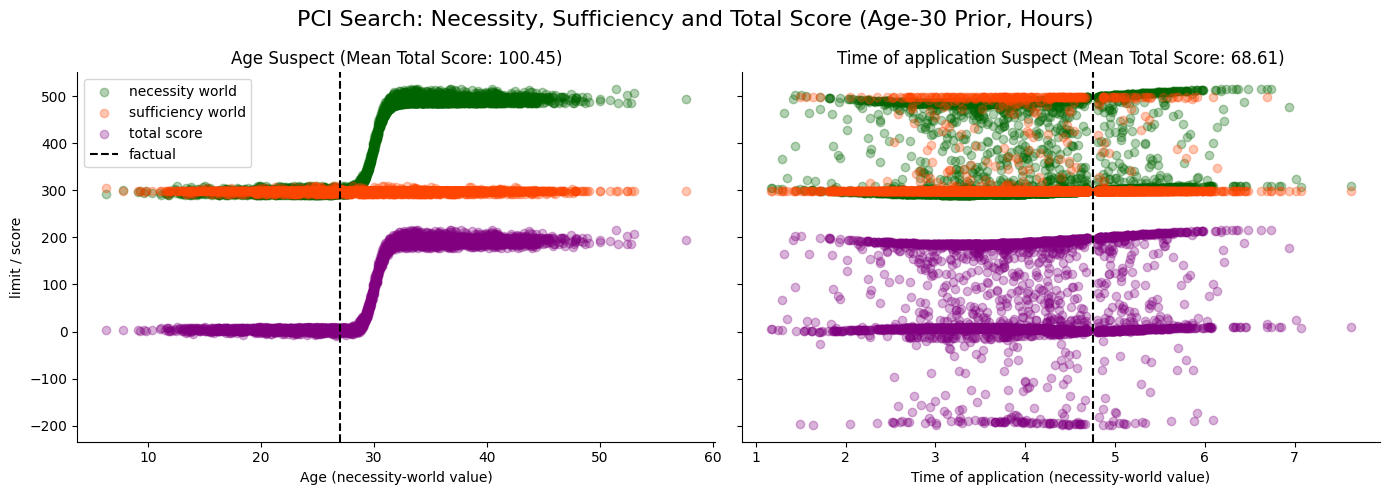

In [22]:
index_of_interest = 250

factuals = {}  # type: ignore
for name, obs in obs_map_for_plotting.items():
    factuals[name] = {}
    for var in obs["continuous"].keys():
        factuals[name][var] = obs["continuous"][var][index_of_interest, ...].item()

plot_mechanism_combined(
    all_conditioned_samples=all_conditioned_samples,
    all_suspect_scores=all_suspect_scores,
    factuals=factuals,
    model_name="hours_age1",
    index_of_interest=index_of_interest,
)

Reading the two panels: in both, the sufficiency-world outcomes (orange) cluster near the factual limit, while the necessity-world outcomes (green) fan out, tracing the deterministic response curve, since changing the suspect *does* move the outcome. The purple score picks up the gap between the two clouds. The displacement is markedly larger for age than for time of application, so the age panel reports the higher mean total score. This is the same model used to produce Figure&nbsp;`fig:mechanism` in the paper. (The cell saves it as `dce/search_samples_combined.png`.)


In [23]:
# Mean total scores at the factual index, for the robustness table in the paper.
# Rows: age suspect, time suspect; columns: {hours, minutes} x {age-30 (age1), age-40 (age2)}.
suspect_label = {"age_norm": "age", "hour_norm": "time", "minute_norm": "time"}
table_rows: dict[str, dict[str, float]] = {"age": {}, "time": {}}
for model_name in ["hours_age1", "minutes_age1", "hours_age2", "minutes_age2"]:
    for suspect, scores in all_suspect_scores[model_name].items():
        m = scores["total"][:, index_of_interest, ...].nanmean().item()
        table_rows[suspect_label[suspect]][model_name] = m

mean_table = pd.DataFrame(table_rows).T[
    ["hours_age1", "minutes_age1", "hours_age2", "minutes_age2"]
]
mean_table.columns = ["age-30 (hrs)", "age-30 (min)", "age-40 (hrs)", "age-40 (min)"]
print(f"MEAN TOTAL SCORES (factual index {index_of_interest}):")
print(mean_table.round(2).to_string())

MEAN TOTAL SCORES (factual index 250):
      age-30 (hrs)  age-30 (min)  age-40 (hrs)  age-40 (min)
age         100.45         97.95        177.87        176.56
time         68.61         66.51        117.97        118.42


The cell below aggregates the mean total scores into the robustness table reproduced in the paper (Table&nbsp;`tab:dce_means`): rows are the two suspects, columns are the four settings (time unit $\times$ age prior). Two patterns to look for. **Across rows:** age outscores time of application in every column, matching the construction. **Across columns:** the "hrs" and "min" pairs agree for each prior (scale invariance), while moving from the age-$30$ to the age-$40$ prior lifts every score (prior sensitivity, since the factual ages are more unusual under the age-$40$ prior).


In [24]:
print(all_suspect_scores.keys())

mean_total_scores_hours_age_1_age = all_suspect_scores["hours_age1"]["age_norm"][
    "total"
].nanmean(dim=0)
mean_total_scores_hours_age_2_age = all_suspect_scores["hours_age2"]["age_norm"][
    "total"
].nanmean(dim=0)

mean_total_scores_hours_age_1_hour = all_suspect_scores["hours_age1"]["hour_norm"][
    "total"
].nanmean(dim=0)
mean_total_scores_hours_age_2_hour = all_suspect_scores["hours_age2"]["hour_norm"][
    "total"
].nanmean(dim=0)


mean_total_scores_minutes_age_1 = all_suspect_scores["minutes_age1"]["age_norm"][
    "total"
].nanmean(dim=0)
mean_total_scores_minutes_age_2 = all_suspect_scores["minutes_age2"]["age_norm"][
    "total"
].nanmean(dim=0)

mean_total_scores_minutes_age_1_minute = all_suspect_scores["minutes_age1"][
    "minute_norm"
]["total"].nanmean(dim=0)
mean_total_scores_minutes_age_2_minute = all_suspect_scores["minutes_age2"][
    "minute_norm"
]["total"].nanmean(dim=0)


scoring_dict = inputs_of_interest.copy()
scoring_dict_minutes = inputs_of_interest_minutes.copy()

scoring_dict["mean_total_scores_hours_age_1_age"] = mean_total_scores_hours_age_1_age
scoring_dict["mean_total_scores_hours_age_2_age"] = mean_total_scores_hours_age_2_age
scoring_dict["mean_total_scores_hours_age_1_hour"] = mean_total_scores_hours_age_1_hour
scoring_dict["mean_total_scores_hours_age_2_hour"] = mean_total_scores_hours_age_2_hour

scoring_dict_minutes["mean_total_scores_minutes_age_1_age"] = (
    mean_total_scores_minutes_age_1
)
scoring_dict_minutes["mean_total_scores_minutes_age_1_minute"] = (
    mean_total_scores_minutes_age_1_minute
)

scoring_dict_minutes["mean_total_scores_minutes_age_2_age"] = (
    mean_total_scores_minutes_age_2
)
scoring_dict_minutes["mean_total_scores_minutes_age_2_minute"] = (
    mean_total_scores_minutes_age_2_minute
)

scoring_dict = {k: v.flatten().numpy() for k, v in scoring_dict.items()}  # type: ignore
scoring_dict_minutes = {k: v.flatten().numpy() for k, v in scoring_dict_minutes.items()}  # type: ignore

scoring_df_hours = pd.DataFrame(scoring_dict)
scoring_df_minutes = pd.DataFrame(scoring_dict_minutes)

dict_keys(['hours_age1', 'hours_age2', 'minutes_age1', 'minutes_age2'])


In [25]:
print(scoring_df_hours.head())

print(scoring_df_minutes.head())

   age_norm  hour_norm  mean_total_scores_hours_age_1_age  \
0      20.0       0.00                          94.517586   
1      20.0       0.25                          95.747993   
2      20.0       0.50                          96.072365   
3      20.0       0.75                          96.011978   
4      20.0       1.00                          93.545433   

   mean_total_scores_hours_age_2_age  mean_total_scores_hours_age_1_hour  \
0                         172.323456                           64.063408   
1                         171.451141                           66.859779   
2                         170.599274                           65.647232   
3                         172.204391                           63.485779   
4                         173.111710                           62.604679   

   mean_total_scores_hours_age_2_hour  
0                          111.227272  
1                          110.673592  
2                          109.741135  
3               

### Priors move the PCI score; rescaling leaves it fixed

Before turning to DCE, we sanity-check the two robustness claims about PCI directly on the grid. The scatter plots below put the age score on the $x$-axis against the time score on the $y$-axis, with a dashed $y=x$ reference line; each point is one grid location. If age is more responsible than time, all points should sit *below* the diagonal.

The four panels vary the two axes of the experiment: the age prior (Age 1 = mean $30$, Age 2 = mean $40$) and the time unit (hours vs.\ minutes). Reading across the panels isolates the two effects. Comparing the hours and minutes panels for a fixed prior tests **invariance to scale**: the clouds should look the same. Comparing Age 1 to Age 2 tests **sensitivity to the prior**: the more unusual factual ages under the age-$40$ prior should push the scores up. In short, we want the picture to move when the prior changes and stay put when only the units change.


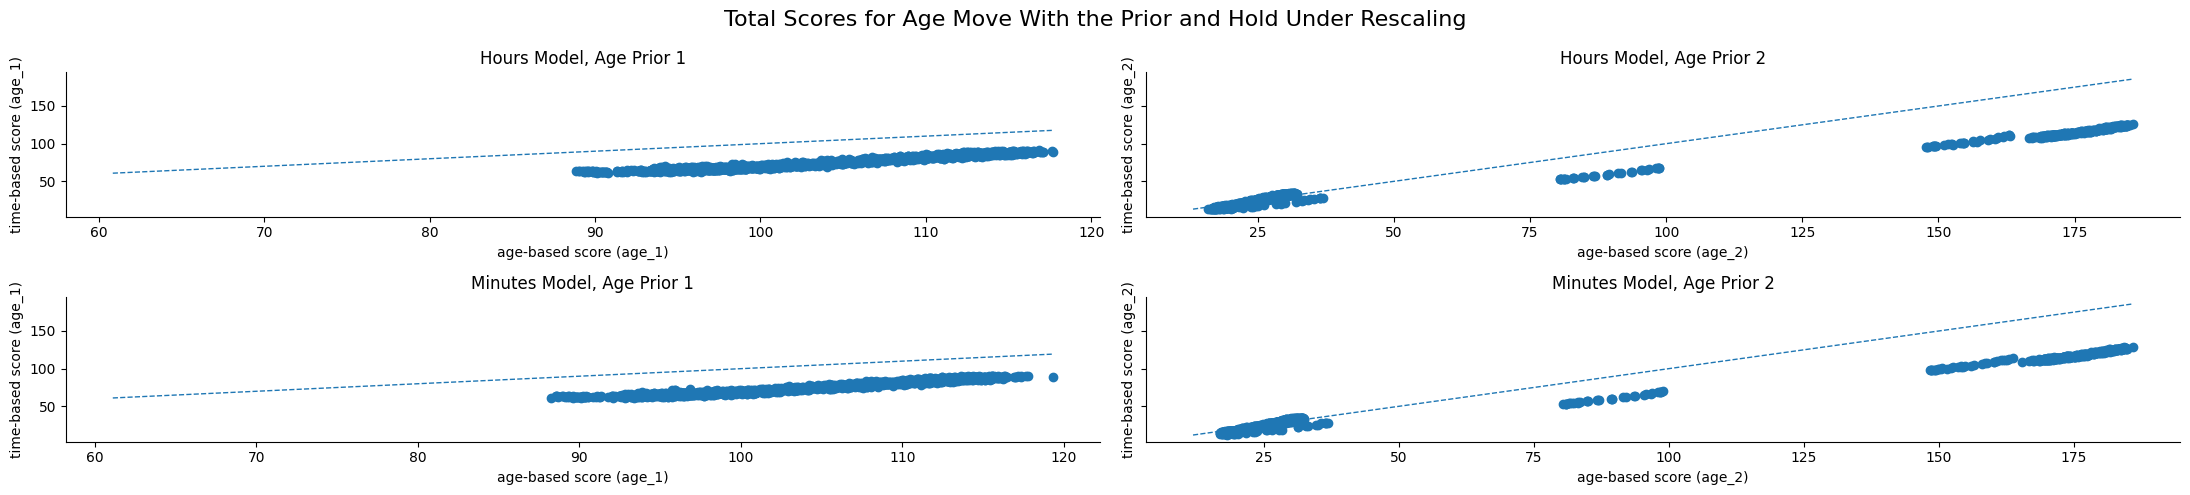

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(22, 5), sharey=True)

axes = axes.flatten()


def add_xy_line(ax, data_x, data_y):
    low = min(data_x.min(), data_y.min())
    high = max(data_x.max(), data_y.max())
    ax.plot([low, high], [low, high], linestyle="--", linewidth=1)


# -------- HOURS DF --------


# subplot 1: age_1 (hours)
x1 = scoring_df_hours["mean_total_scores_hours_age_1_age"]
y1 = scoring_df_hours["mean_total_scores_hours_age_1_hour"]
axes[0].scatter(x1, y1)
add_xy_line(axes[0], x1, y1)
axes[0].set_title("Hours Model, Age Prior 1")
axes[0].set_xlabel("age-based score (age_1)")
axes[0].set_ylabel("time-based score (age_1)")
sns.despine(ax=axes[0])

# subplot 2: age_2 (hours)
x2 = scoring_df_hours["mean_total_scores_hours_age_2_age"]
y2 = scoring_df_hours["mean_total_scores_hours_age_2_hour"]
axes[1].scatter(x2, y2)
add_xy_line(axes[1], x2, y2)
axes[1].set_title("Hours Model, Age Prior 2")
axes[1].set_xlabel("age-based score (age_2)")
axes[1].set_ylabel("time-based score (age_2)")
sns.despine(ax=axes[1])


# -------- MINUTES DF --------

# subplot 3: age_1 (minutes)
x3 = scoring_df_minutes["mean_total_scores_minutes_age_1_age"]
y3 = scoring_df_minutes["mean_total_scores_minutes_age_1_minute"]
axes[2].scatter(x3, y3)
add_xy_line(axes[2], x3, y3)
axes[2].set_title("Minutes Model, Age Prior 1")
axes[2].set_xlabel("age-based score (age_1)")
axes[2].set_ylabel("time-based score (age_1)")
sns.despine(ax=axes[2])

# subplot 4: age_2 (minutes)
x4 = scoring_df_minutes["mean_total_scores_minutes_age_2_age"]
y4 = scoring_df_minutes["mean_total_scores_minutes_age_2_minute"]
axes[3].scatter(x4, y4)
add_xy_line(axes[3], x4, y4)
axes[3].set_title("Minutes Model, Age Prior 2")
axes[3].set_xlabel("age-based score (age_2)")
axes[3].set_ylabel("time-based score (age_2)")
sns.despine(ax=axes[3])

plt.suptitle(
    "Total Scores for Age Move With the Prior and Hold Under Rescaling", fontsize=16
)

plt.tight_layout()
plt.show()

In [27]:
def plot_diff_contour(
    df,
    time_var,  # "hour_norm" or "minute_norm"
    prefix,  # "hours" or "minutes"
    age_label,  # "age_1" or "age_2"
    levels=15,
):
    """
    df: scoring_df_hours or scoring_df_minutes
    time_var: column storing hour_norm or minute_norm
    prefix: "hours" or "minutes"
    age_label: "age_1" or "age_2"
    """

    # Construct correct column names
    col_age_score = f"mean_total_scores_{prefix}_{age_label}_age"
    col_time_score = f"mean_total_scores_{prefix}_{age_label}_{time_var.split('_')[0]}"

    # Extract values
    score_age = df[col_age_score].values
    score_time = df[col_time_score].values

    ages = df["age_norm"].values
    times = df[time_var].values

    # Reshape into mesh
    unique_ages = np.unique(ages)
    unique_times = np.unique(times)

    nA = len(unique_ages)
    nT = len(unique_times)

    A = ages.reshape(nA, nT)
    T = times.reshape(nA, nT)

    Z_age = score_age.reshape(nA, nT)
    Z_time = score_time.reshape(nA, nT)

    Z_diff = Z_age - Z_time

    # ---- PLOT ----
    plt.figure(figsize=(8, 6))
    cmap = "cividis"

    # Use more levels for smoother shading

    # Filled contour
    cont = plt.contourf(A, T, Z_diff, levels=levels, cmap=cmap)

    # Very thin outer contour lines (optional but clearer)
    plt.contour(A, T, Z_diff, levels=levels, colors="black", linewidths=0.25, alpha=0.4)

    plt.xlabel("age of applicant")
    plt.ylabel("time of application")
    plt.title(
        "Difference: Age Score − Time Of Application Score (Hours, Age_1)",
    )

    plt.colorbar(cont, label="difference (age score − time score)")

    plt.suptitle(
        "Age Outscores Time of Application at Every Point on the Grid",
        fontsize=16,
    )

    plt.tight_layout()

    fig_path = f"dce/contour_diff_{prefix}_{age_label}.png"
    plt.savefig(fig_path, dpi=300)

    plt.show()


# TODO generalize to minutes too, perhaps

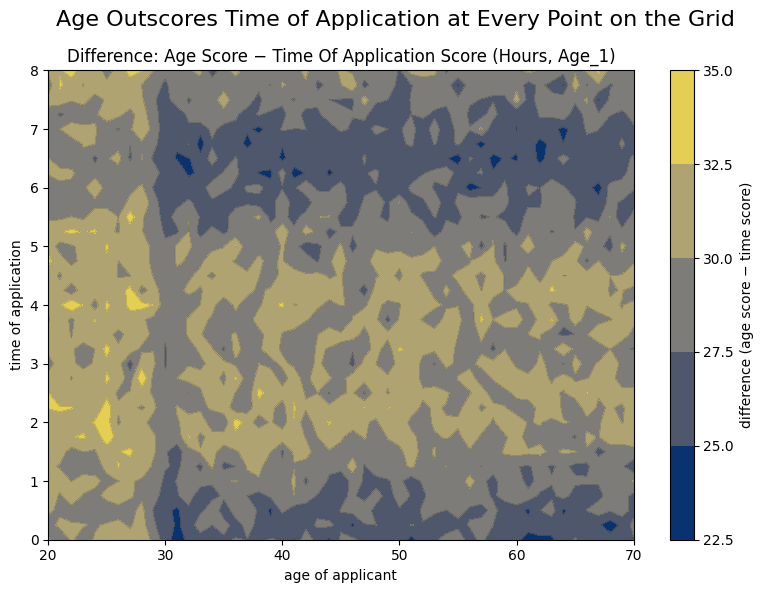

In [28]:
plot_diff_contour(
    scoring_df_hours, time_var="hour_norm", prefix="hours", age_label="age_1", levels=4
)

In [29]:
# (age-40 contour omitted in the simplified figure set: the age-30 contour above is
#  representative, and the other settings give the same qualitative picture. See paper text.)

### Differential causal effect

Now we compute the baseline we are contrasting against. The differential causal effect (DCE) of an input is the partial derivative of the model output with respect to that input, evaluated at the factual point: $\partial_{x_i} m(\mathbf{x})$. Since our deterministic component $F$ is differentiable, we can read this off directly with automatic differentiation, with no Monte Carlo search.

The helper below takes the grid of input values, marks `age_norm` and the time variable as `requires_grad=True`, runs them through the internal model, and calls `torch.autograd.grad` to obtain $\partial F/\partial \text{age}$ and $\partial F/\partial \text{time}$ at every grid point. We do this once on the hour scale and once on the minute scale so that we can see how a pure change of units affects the gradient. The contrast with PCI: DCE needs only a forward/backward pass through a differentiable $F$, whereas PCI needed the full sample-condition-score pipeline above. DCE also inherits the units of $Y$ per unit of $X$, and the unit-rescaling test exposes exactly that.


In [30]:
def add_gradient_scores(df_inputs, model, time_var="hour_norm", grad_prefix="grad"):
    """
    Compute gradients of model output w.r.t age_norm and time_var, and add them to df_inputs.

    Args:
        df_inputs: pd.DataFrame containing 'age_norm' and time_var
        model: callable model(age_tensor, time_tensor)
        time_var: str, either 'hour_norm' or 'minute_norm'
        grad_prefix: prefix for new gradient columns

    Returns:
        pd.DataFrame with gradient columns appended
    """
    age_grad = torch.tensor(
        df_inputs["age_norm"].values, dtype=torch.float32, requires_grad=True
    )
    time_grad = torch.tensor(
        df_inputs[time_var].values, dtype=torch.float32, requires_grad=True
    )

    grads_age = []
    grads_time = []

    N = len(df_inputs)

    for i in range(N):
        age_i = age_grad[i : i + 1]
        time_i = time_grad[i : i + 1]

        out = model(age_i, time_i)

        grad_age, grad_time = torch.autograd.grad(
            outputs=out, inputs=(age_grad, time_grad), retain_graph=True
        )

        grads_age.append(grad_age[i])
        grads_time.append(grad_time[i])

    # Stack and convert to numpy
    grads_age = torch.stack(grads_age).numpy()
    grads_time = torch.stack(grads_time).numpy()

    # Append to DataFrame
    df_inputs[f"{grad_prefix}_age_norm"] = grads_age
    df_inputs[f"{grad_prefix}_{time_var}"] = grads_time

    return df_inputs

In [31]:
# Hours model
scoring_df_hours = add_gradient_scores(
    scoring_df_hours,
    internal_model_hours,
    time_var="hour_norm",
    grad_prefix="grad_hours",
)

# Minutes model
scoring_df_minutes = add_gradient_scores(
    scoring_df_minutes,
    internal_model_minutes,
    time_var="minute_norm",
    grad_prefix="grad_minutes",
)

In [32]:
display(scoring_df_minutes.head())

,age_norm,minute_norm,mean_total_scores_minutes_age_1_age,mean_total_scores_minutes_age_1_minute,mean_total_scores_minutes_age_2_age,mean_total_scores_minutes_age_2_minute,grad_minutes_age_norm,grad_minutes_minute_norm
0,20.0,0.0,95.850647,64.947624,171.312485,112.795670,8.491953e-07,-6.338002e-09
1,20.0,15.0,95.088326,66.667442,169.926147,111.865868,8.484766e-07,-3.469996e-02
2,20.0,30.0,97.548485,68.142998,170.527649,113.504463,8.463622e-07,-6.738329e-02
3,20.0,45.0,95.933380,63.564137,172.359634,113.323616,8.429751e-07,-9.615052e-02
4,20.0,60.0,96.415512,63.972469,172.443634,114.362335,8.385119e-07,-1.193299e-01


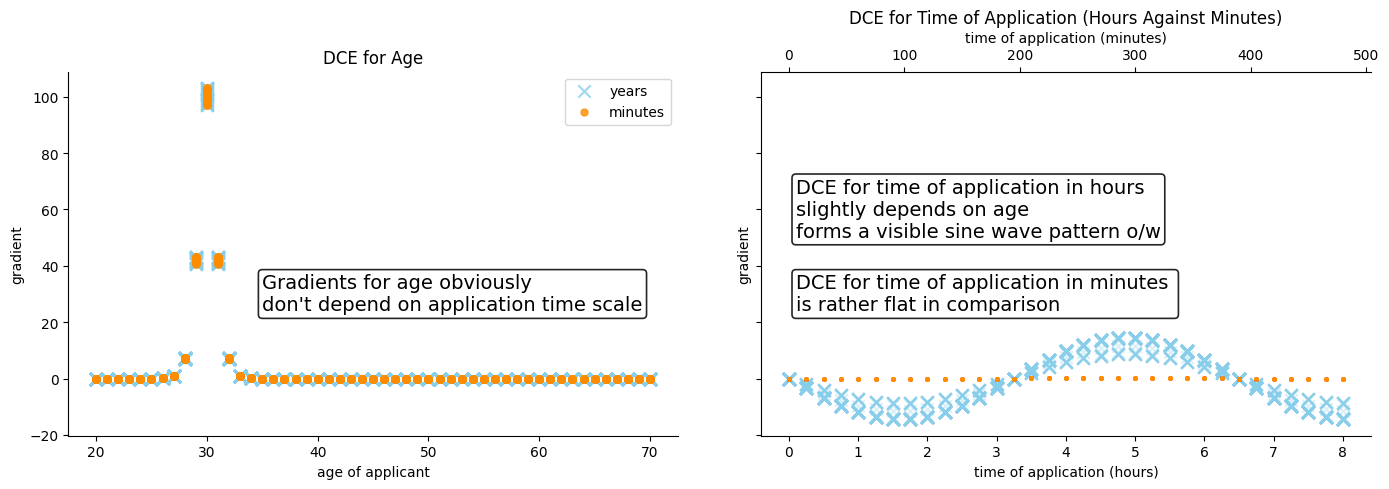

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)


df = scoring_df_hours
age_col = "age_norm"
time_col = "hour_norm"
age_grad_col = "grad_hours_age_norm"
time_grad_col = "grad_hours_hour_norm"


axes[0].scatter(
    df[age_col],
    df[age_grad_col],
    alpha=0.8,
    s=80,
    label="years",
    marker="x",
    color="skyblue",
)
axes[0].set_xlabel("age of applicant")
axes[0].set_ylabel("gradient")
axes[0].set_title("DCE for Age")
axes[0].legend()


axes[1].scatter(
    df[time_col],
    df[time_grad_col],
    alpha=0.3,
    s=80,
    label="years",
    marker="x",
    color="skyblue",
)
axes[1].set_xlabel("time of application (hours)")
axes[1].set_ylabel("gradient")
axes[1].set_title("DCE for Time of Application (Hours Against Minutes)")

add_line_end_label(
    axes[1],
    0.1,
    60,
    "DCE for time of application in hours \nslightly depends on age \nforms a visible sine wave pattern o/w",
)

add_line_end_label(
    axes[1],
    0.1,
    30,
    "DCE for time of application in minutes \nis rather flat in comparison",
)


df = scoring_df_minutes
age_col = "age_norm"
time_col = "minute_norm"
age_grad_col = "grad_minutes_age_norm"
time_grad_col = "grad_minutes_minute_norm"

axes[0].scatter(
    df[age_col], df[age_grad_col], alpha=0.8, s=25, label="minutes", color="darkorange"
)
axes[0].set_ylabel("gradient")
axes[0].set_title("DCE for Age")
axes[0].legend()

add_line_end_label(
    axes[0],
    35,
    30,
    "Gradients for age obviously \ndon't depend on application time scale",
)


ax_minutes = axes[1].secondary_xaxis(
    "top",
    functions=(
        lambda h: h * 60,  # convert hours → minutes for tick display
        lambda m: m / 60,  # convert minutes → hours to map coords
    ),
)

ax_minutes.set_xlabel("time of application (minutes)")


axes[1].scatter(
    df[time_col] / 60,
    df[time_grad_col],
    alpha=0.3,
    s=5,
    label="minutes",
    color="darkorange",
)

sns.despine()
plt.tight_layout()
file_path = "dce/dce_age_time_hours_minutes.png"
plt.savefig(file_path, dpi=300)
plt.show()

**How to read the DCE plot.** The left panel shows the gradient with respect to age; it is unaffected by the time unit (the years/minutes markers coincide), as it should be. The right panel shows the gradient with respect to time of application, on both scales. Two things stand out and both are problems for using DCE as a responsibility score. First, on the hour scale the time gradient traces a visible sine wave whose magnitude rivals or exceeds the age gradient over much of the grid — so DCE would rank time of application as comparably or more influential than age, contradicting the construction in which age dominates. Second, switching from hours to minutes flattens the time gradient by roughly a factor of $60$: the very same causal mechanism is assigned a much smaller "effect" purely because we relabelled the $x$-axis. This is the unit sensitivity discussed at the top of the notebook, made concrete. Compare with the PCI contour earlier, which put age above time everywhere and barely moved under the same rescaling.


## Conclusions

This notebook ran a single, deliberately simple causal model through two lenses and compared their verdicts on a continuous-input attribution problem.

- Two methods, two questions. DCE asks *"how fast does the outcome change if I nudge this input?"*, a local rate of change. PCI asks *"in this individual case, how responsible was this input for the outcome we actually observed?"*, an individual-level responsibility score. They are not direct competitors, though PCI inherits the territory of continuous attribution, so the contrast is informative.

- Faithfulness to the obvious answer. In the credit-limit model age is built to dominate: it moves the limit by hundreds of dollars, while time of day contributes only a small sinusoidal wiggle. PCI recovers this: its age score exceeds its time score in every setting (roughly $100$ vs.\ $69$ on the canonical setting, and the age-minus-time difference is positive everywhere on the grid). DCE does not: on the hour scale the gradient for time of application actually *exceeds* the gradient for age over most of the grid. A method's numbers can look plausible and still be causally unfaithful.

- Unit (in)variance. Rescaling time from hours to minutes is a cosmetic change that should not affect attribution. It leaves the PCI scores essentially unchanged (the "hrs" and "min" columns of the table agree), because PCI integrates inputs out against their necessity- and sufficiency-world densities rather than reading off a raw derivative. The same rescaling flattens the time DCE by roughly a factor of $60$, because a derivative carries the units of $Y$ per unit of $X$.

- Sensitivity to priors, not to scale. How unusual the factual input is *should* matter, and it does move the PCI score: shifting the age prior from a mean of $30$ to $40$ raises every score, because a more atypical factual age means a larger displacement in the search space. PCI responds to genuine changes in the causal context while ignoring arbitrary reparameterisations.

Section&nbsp;6 of the paper (*Comparison to Differential Causal Effect*) develops these points. Gradient and sensitivity attributions answer a different question from causal responsibility, and the difference shows even on a model this small.
